# Adaptive QCNN, solving reg problem - gen_linear - get weights

## Install packages

In [1]:
# %pip install numpy
# %pip install pandas
# %pip install matplotlib
# %pip install scikit-learn
# %pip install pylatexenc

# %pip install qiskit==1.2.4
# %pip install qiskit_aer==0.15.1
# # %pip install qiskit_algorithms
# %pip install qiskit_ibm_runtime==0.29.0
# %pip install qiskit_machine_learning==0.8.1

# %pip install pennylane==0.39.0
# %pip install pennylane_qiskit==0.39.1

# %pip install torch==2.5.0
# %pip install torchvision==0.20.0
# %pip install tensorflow==2.17.0

In [2]:
import random
import numpy as np

import qiskit
import qiskit_ibm_runtime
import qiskit_machine_learning
import qiskit_aer

import pennylane as qml
import pennylane_qiskit
from pennylane import numpy as pnp

import torch
import torchvision
import tensorflow as tf

In [3]:
print("Packge version:")
print("  qiskit:", qiskit.__version__)
print("  qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)
print("  qiskit-machine-learning:", qiskit_machine_learning.__version__)
print("  qiskit-Aer:", qiskit_aer.__version__)
print("")
print("  pennylane:", qml.__version__)
print("  pennylane-qiskit:", pennylane_qiskit.__version__)
print("")
print("  torch:", torch.__version__)
print("  torchvision:", torchvision.__version__)
print("  tensorflow:", tf.__version__)

Packge version:
  qiskit: 1.2.4
  qiskit-ibm-runtime: 0.29.0
  qiskit-machine-learning: 0.8.1
  qiskit-Aer: 0.15.1

  pennylane: 0.38.0
  pennylane-qiskit: 0.39.1

  torch: 2.5.0+cpu
  torchvision: 0.20.0+cpu
  tensorflow: 2.17.0


## Preparing Simulation Setups:

### Load your IBM account with instance, and quantum backend

In [4]:
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(
#     instance='ibm-q-yonsei/internal/default',
#     # instance='yonsei-dedicated/researchyonsei/d-parklab'
# )
# service

In [5]:
# # List all available backends (quantum devices and simulators)
# backend_list = service.backends(
#     simulator=False,
#     operational=True,
#     min_num_qubits=127
#     )

# print("List of available devices:")
# for backend in backend_list:
#     print('  ', backend.name)

In [6]:
# Select the backend of your choice. If None, the least busy backend will be selected.
# AVAILABLE BACKEND: 
# instance: 'ibm-q-yonsei/internal/default' -> ibm_brussels, ibm_fez, ibm_strasbourg, ibm_sherbrooke, ibm_brisbane, ibm_nazca, ibm_torino, ibm_kyiv,
# instance: 'yonsei-dedicated/researchyonsei/d-parklab' -> ibm_yonsei

# backend_select = None
# backend_select = "ibm_nazca"
backend_select = "ibm_yonsei"

# if backend_select == None:
#     backend = service.least_busy(operational=True, simulator=False)
# else:
#     backend = service.backend(backend_select)
# print('backend:', backend)

In [7]:
# Choose quantum backend
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2
from qiskit_ibm_runtime import QiskitRuntimeService

def choose_backend(noise_setting, backend_select = None, num_shots = 1024):
    # Declare ibm quantum service
    if backend_select == 'ibm_yonsei':
        # instance = 'yonsei-dedicated/researchyonsei/d-parklab'
        name = 'yonsei_qdna'
    else:
        # instance = 'ibm-q-yonsei/internal/default'
        name = 'yonsei_internal'
    # Load qiskit runtime service
    service = QiskitRuntimeService(name = name)

    # Assign quantum backend
    if noise_setting == '0':
        backend = AerSimulator()
    elif noise_setting == '1':
        backend = FakeGuadalupeV2()
    elif noise_setting == '2':
        if backend_select == None:
            backend = AerSimulator.from_backend(service.least_busy(operational = True, simulator = False))
        else:
            backend = AerSimulator.from_backend(service.backend(backend_select))
    elif noise_setting == '3':
        if backend_select == None:
            backend = service.least_busy(operational = True, simulator = False)
        else:
            backend = service.backend(backend_select)
    
    # Assign number of shots
    backend.options.shots = num_shots
    
    return service, backend

### SIMULATION HYPERPARAMETERS TO CHANGE

In [8]:
# Noise setting and dataset name
noise_setting = '0'

# Number of qubits
num_qubits = 8      # 4, 8, 10

# Problem and dataset
problem_type = 'reg'
dataset_type = 'gen_linear'
dataset_dir = 'dataset_mr_w_error'     # 'dataset_mr_w_error'
dataset_name = f'{dataset_type}_{dataset_dir}'

# device name
noise_to_device = {'0': 'noiseless',
                   '1': 'FakeGuadalupeV2',
                   '2': 'AerSim_with_backend_noise',
                   '3': 'IBM_Quantum_backend'}
device_name = noise_to_device.get(noise_setting, 'UnknownDevice')

# IBM service and backend
num_shots = 1024
service, backend = choose_backend(noise_setting = noise_setting,
                                  backend_select = backend_select,
                                  num_shots = num_shots)

print('noise_setting:', noise_setting)
print('num_qubits:', num_qubits)
print('device_name:', device_name)
print("service:", service)
print("backend:", backend)
print('dataset_name:', dataset_name)

noise_setting: 0
num_qubits: 8
device_name: noiseless
service: <QiskitRuntimeService>
backend: AerSimulator('aer_simulator')
dataset_name: gen_linear_dataset_mr_w_error


In [9]:
# RNG seed_num setting
sim_iter_num = 0

seed_num_list = [42, 123, 9876, 555, 876543, 999, 654, 314159, 777, 8888]
# new_seeds_set = [7, 17, 29, 73, 101, 211, 313, 523, 947, 2027]
seed_num = seed_num_list[sim_iter_num]

print('sim_iter_num:', sim_iter_num)
print('seed_num:', seed_num)

sim_iter_num: 0
seed_num: 42


In [10]:
# Define function to fix the random seed number
from qiskit_machine_learning.utils import algorithm_globals

def set_seed(seed):
    random.seed(seed)
    
    np.random.seed(seed)
    
    qml.numpy.random.seed(seed)
    
    algorithm_globals.random_seed = seed
        
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # If using multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    tf.random.set_seed(seed)

set_seed(seed_num)

### Create Result Folder
- This code creates a folder to save our model's results.
- If the folder doesn't exist, it makes one.
    - `save_dir`: string. name of the folder to be saved.

In [11]:
# Define the folder name
save_dir = f'save_results_{problem_type}/{dataset_name}_{num_qubits}/'

# # Create the folder if it doesn't exist
# import os
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)
# print('save_dir:', save_dir)

## Load the dataset: generated linear dataset

### SUBSET THE DATASET IF NEEDED TO CHANGE

In [12]:
# ############# Subset the dataset if needed ############# (reduce the dataset size)
n_train_size = 100          # len(data_train)
n_val_size = 20             # len(data_val)
n_test_size = 100           # len(data_test)

batch_size = 10
# ########################################################

In [13]:
import numpy as np

## Load the generated dataset
data_dir = f'{problem_type}_dataset/{dataset_type}/{dataset_dir}/'

data_train = np.loadtxt(data_dir + f'data_train_feature{num_qubits}.txt', delimiter='\t')
data_val = np.loadtxt(data_dir + f'data_val_feature{num_qubits}.txt', delimiter='\t')
data_test = np.loadtxt(data_dir + f'data_test_feature{num_qubits}.txt', delimiter='\t')

column_names = [f'feature{i+1}' for i in range(num_qubits)] + ['target']
data = data_train

print('----------Generated dataset----------')
print('- column_names:', column_names, '\n')
print('data_train:\n', data_train[0:10])
print('data_train.shape:\n', data_train.shape, '\n')
print('data_val:\n', data_val[0:10])
print('data_val.shape:\n', data_val.shape, '\n')
print('data_test:\n', data_test[0:10])
print('data_test.shape:\n', data_test.shape, '\n')

----------Generated dataset----------
- column_names: ['feature1', 'feature2', 'feature3', 'feature4', 'feature5', 'feature6', 'feature7', 'feature8', 'target'] 

data_train:
 [[ 1.21127904  1.26872851  0.89080517  1.46064886  1.27439929  1.60859771
   1.31206174  2.74336663 -0.093069  ]
 [ 0.90151565  1.11794009  1.05782168  0.19983748  2.22340383  2.96802077
   0.91596145  1.89192767 -0.27258253]
 [ 2.07219421  1.62039     2.38066799  1.20633949  2.07160414  1.59712688
   1.77229078  1.43420743  0.16008958]
 [ 1.76938537  0.33076569  1.7854471   0.91518301  1.22698481  2.16652614
   2.12364044  2.13515427 -0.21116663]
 [ 1.62217651  1.57647254  1.88062305  1.35180094  1.15640539  2.07993262
   2.54666435  2.40864564  0.433984  ]
 [ 2.34266164  0.76543694  1.47554995  0.87600082  2.54711134  1.91014383
   2.12406048  0.53911157 -0.47863573]
 [ 1.87983011  1.98038132  1.52292497  1.47930021  2.07669534  1.54095315
   1.72254648  1.52846764  0.13426129]
 [ 0.94083726  1.60716364  2.2915

In [14]:
# # ############# Subset the dataset if needed ############# (reduce the dataset size)
# X_train = data_train[0:n_train_size,:-1]
# Y_train = data_train[0:n_train_size,-1]

# X_val = data_val[0:n_val_size,:-1]
# Y_val = data_val[0:n_val_size,-1]

# X_test = data_test[0:n_test_size,:-1]
# Y_test = data_test[0:n_test_size,-1]

# Split data_train into features and target
X_train = data_train[:, :-1]
Y_train = data_train[:, -1]

# Split data_val into features and target
X_val = data_val[:, :-1]
Y_val = data_val[:, -1]

# Split data_test into features and target
X_test = data_test[:, :-1]
Y_test = data_test[:, -1]

# Check the shapes to ensure correct splitting
print('X_train shape:', X_train.shape)
print('X_train type:', type(X_train))
print('y_train shape:', Y_train.shape)
print('y_train type:', type(Y_train))
print('X_val shape:', X_val.shape)
print('X_val type:', type(X_val))
print('y_val shape:', Y_val.shape)
print('y_val type:', type(Y_val))
print('X_test shape:', X_test.shape)
print('X_test type:', type(X_test))
print('y_test shape:', Y_test.shape)
print('y_test type:', type(Y_test))

X_train shape: (100, 8)
X_train type: <class 'numpy.ndarray'>
y_train shape: (100,)
y_train type: <class 'numpy.ndarray'>
X_val shape: (20, 8)
X_val type: <class 'numpy.ndarray'>
y_val shape: (20,)
y_val type: <class 'numpy.ndarray'>
X_test shape: (20, 8)
X_test type: <class 'numpy.ndarray'>
y_test shape: (20,)
y_test type: <class 'numpy.ndarray'>


### Convert dataset into a PyTorch dataset for model optimization

In [15]:
import torch
from torch import manual_seed, tensor, Tensor, float32
from torch.utils.data import Dataset, DataLoader

# Train, Validation, and Test Dataset (features, target)
# -------------

# Define your custom dataset class
class MyDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]


# # Test Dataset (only features)
# # -------------

# # Define your custom dataset class
# class MyDataset_test(Dataset):
#     def __init__(self, data):
#         self.data = data

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         return self.data[idx]

In [16]:
# Set train shuffle seed (for reproducibility)
manual_seed(seed_num)

# Convert data and labels to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float)

# Create an instance of your custom dataset
train_dataset = MyDataset(X_train_tensor, Y_train_tensor)

#-----
# Convert data and labels to tensors
X_val_tensor = torch.tensor(X_val, dtype=torch.float)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float)

# Create an instance of your custom dataset
val_dataset = MyDataset(X_val_tensor, Y_val_tensor)

#----
# Convert data and labels to tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float)

# Create an instance of your custom dataset
test_dataset = MyDataset(X_test_tensor, Y_test_tensor)

#----

# Define torch dataloader with filtered data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [17]:
# Set higher precision for printing
torch.set_printoptions(precision=10)

# Print out the `train_dataset`, `val_dataset`, and `test_dataset` outputs
print('----------train_dataset----------')
print('- dataset features(head):\n', train_dataset.data[0:10])
print('- dataset features shape:\n', train_dataset.data.shape)
print('- dataset target(head):\n', train_dataset.targets[0:10])
print('- dataset target shape:\n', train_dataset.targets.shape)
print('-type:\n', type(train_dataset), '\n')

print('----------val_dataset----------')
print('- dataset features(head):\n', val_dataset.data[0:10])
print('- dataset features shape:\n', val_dataset.data.shape)
print('- dataset target(head):\n', val_dataset.targets[0:10])
print('- dataset target shape:\n', val_dataset.targets.shape)
print('-type:\n', type(val_dataset), '\n')

print('----------test_dataset----------')
print('- dataset features(head):\n', test_dataset.data[0:10])
print('- dataset features shape:\n', test_dataset.data.shape)
print('- dataset target(head):\n', test_dataset.targets[0:10])
print('- dataset target shape:\n', test_dataset.targets.shape)
print('-type:\n', type(test_dataset))

----------train_dataset----------
- dataset features(head):
 tensor([[1.2112790346, 1.2687284946, 0.8908051848, 1.4606488943, 1.2743992805,
         1.6085977554, 1.3120617867, 2.7433667183],
        [0.9015156627, 1.1179400682, 1.0578216314, 0.1998374760, 2.2234039307,
         2.9680206776, 0.9159614444, 1.8919277191],
        [2.0721940994, 1.6203899384, 2.3806679249, 1.2063394785, 2.0716042519,
         1.5971268415, 1.7722908258, 1.4342074394],
        [1.7693853378, 0.3307656944, 1.7854471207, 0.9151830077, 1.2269848585,
         2.1665260792, 2.1236405373, 2.1351542473],
        [1.6221765280, 1.5764725208, 1.8806231022, 1.3518009186, 1.1564054489,
         2.0799326897, 2.5466642380, 2.4086456299],
        [2.3426616192, 0.7654369473, 1.4755499363, 0.8760008216, 2.5471112728,
         1.9101438522, 2.1240603924, 0.5391115546],
        [1.8798301220, 1.9803813696, 1.5229250193, 1.4793002605, 2.0766954422,
         1.5409531593, 1.7225464582, 1.5284676552],
        [0.9408372641,

## Buid Quantum Circuit using IBM Quantum / Qiskit

### Build the QCNN circuits

In [18]:
# num_qubits = 4
num_input = X_train.shape[1]

print('num_qubits:', num_qubits)
print('num_input:', num_input)

num_qubits: 8
num_input: 8


In [19]:
########## QCNN blocks for circuit ##########
# Data Embedding: Angle Embedding
import copy
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, ParameterVector
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.circuit.library import QNNCircuit

# Angle Embedding
def AngleEmbedding(num_feature):
    embed_param = ParameterVector(name = 'x', length = num_feature)
    embedding = QuantumCircuit(num_feature, name = 'AngleEmbedding')
    for i in range(num_feature):
        embedding.ry(embed_param[i], qubit = i)
    embedding = embedding.to_instruction()

    qc = QuantumCircuit(num_feature, name = 'AngleEmbedding')
    qc.append(instruction = embedding, qargs = range(num_feature))
    return qc

def AngleEmbedding_reverse(num_feature):
    embed_param = ParameterVector(name = 'x', length = num_feature)
    embedding = QuantumCircuit(num_feature, name = 'AngleEmbedding-r')
    for i in range(num_feature):
        embedding.ry(embed_param[num_feature - 1 - i], qubit = i)
    embedding = embedding.to_instruction()

    qc = QuantumCircuit(num_feature, name = 'AngleEmbedding-r')
    qc.append(instruction = embedding, qargs = range(num_feature))
    return qc

# Convolution blocks
def ConvSimple(param):
    qc = QuantumCircuit(2, name = "Conv_Simple")
    qc.ry(theta = param[0], qubit = 0)
    qc.ry(theta = param[1], qubit = 1)
    qc.cx(control_qubit = 0, target_qubit = 1)
    gate = qc.to_gate()
    return gate

def ConvSU4(param):
    qc = QuantumCircuit(2, name = "Conv_SU4")
    qc.u(theta = param[0], phi = param[1], lam = param[2], qubit = 0)
    qc.u(theta = param[3], phi = param[4], lam = param[5], qubit = 1)
    qc.cx(control_qubit = 0, target_qubit = 1)
    qc.ry(theta = param[6], qubit = 0)
    qc.rz(phi = param[7], qubit = 1)
    qc.cx(control_qubit = 1, target_qubit = 0)
    qc.ry(theta = param[8], qubit = 0)
    qc.cx(control_qubit = 0, target_qubit = 1)
    qc.u(theta = param[9], phi = param[10], lam = param[11], qubit = 0)
    qc.u(theta = param[12], phi = param[13], lam = param[14], qubit = 1)
    gate = qc.to_gate()
    return gate

# Pooling blocks
def PoolSimple(param):
    qc = QuantumCircuit(2, name = "Pool_Simple")
    qc.crz(theta = param[0], control_qubit = 0, target_qubit = 1, ctrl_state = '1')
    qc.crx(theta = param[1], control_qubit = 0, target_qubit = 1, ctrl_state = '0')
    gate = qc.to_gate()
    return gate

# QCNN circuit: output Feature map
def QCNN_FeatureMap(num_qubits, embed_method):
    if embed_method == 'AngleEmbed':
        feature_map = AngleEmbedding(num_qubits)
    elif embed_method == 'AngleEmbed-r':
        feature_map = AngleEmbedding_reverse(num_qubits)
    elif embed_method == 'ZZFeatureMap':
        feature_map = ZZFeatureMap(num_qubits)
    feature_map.barrier()
    return feature_map

# Measure a qubit with a given basis
def measure_basis(qc, qubit, cbit, meas_basis):
    qc.barrier()
    if meas_basis == 'X':
        qc.h(qubit)
    elif meas_basis == 'Y':
        qc.sdg(qubit)
        qc.h(qubit)
    elif meas_basis == 'Z':
        pass
    qc.measure(qubit, cbit)
    qc.barrier()
    ## Add barrior for mid-circuit measurement.
    ## However, 'StatevectorSampler' cannot handle mid-circuit measurement.

In [20]:
# QCNN circuit: output Ansatz with Measurements
def QCNN_Ansatz_Meas(num_qubits, conv_block = 'ConvSimple', pool_block = 'PoolSimple',
                     multi_meas = False, meas_basis = 'Z', no_boundary = False):  
    # Total number of model parameters (weights) of QCNN
    # if np.log2(num_qubits) != int(np.log2(num_qubits)):
    #     raise ValueError("The n_qubit value must be a power of 2.")
    
    ## circuit parameter
    # conv_param = (number of parameters of the conv_block) * (number of layers)
    # pool_param = (number of parameters of the pool_block) * (number of layers)
    block_param_dict = {'ConvSimple': 2, 'ConvSU4': 15, 'PoolSimple': 2, None: 0}
    num_conv_param = block_param_dict[conv_block]
    num_pool_param = block_param_dict[pool_block] if pool_block else 0
    layer_num = 0
    layer_num_last = int((np.ceil(np.log2(num_qubits))))
    total_param_len = (num_conv_param + num_pool_param) * layer_num_last
    weight_param = ParameterVector(name = 'θ', length = total_param_len)
    
    ## Ansatz and Measurements
    block_index = list(range(num_qubits))
    ansatz_blocks = {'ConvSimple': ConvSimple, 'ConvSU4': ConvSU4, 'PoolSimple': PoolSimple}
    conv_func = ansatz_blocks[conv_block]
    pool_func = ansatz_blocks[pool_block] if pool_block else None
       
    q_reg = QuantumRegister(size = num_qubits, name = 'q')
    ansatz = QuantumCircuit(q_reg, name = 'QCNN_Ansatz')
    if not multi_meas:
        output_dim = 1
    else:
        output_dim = int(np.ceil(np.log2(num_qubits)))
    c_reg = ClassicalRegister(size = output_dim, name = 'c')
    ansatz.add_register(c_reg)
    
    ## QCNN circuit build with mid-circuit measurements
    if not (num_qubits == 8 and pool_block is None and no_boundary):
        ### For len(block_index) > 2:
        while len(block_index) > 2:
            layer_num += 1
            ## Convolution and Pooling
            conv_index = (layer_num - 1) * num_conv_param
            pool_index = layer_num_last * num_conv_param + (layer_num - 1) * num_pool_param
            
            for i in range(0, len(block_index), 2):
                if i + 1 >= len(block_index) and no_boundary:
                    continue           
                ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                              qargs = [block_index[i], block_index[(i + 1) % len(block_index)]])
            for i in range(1, len(block_index), 2):
                if i + 1 >= len(block_index) and no_boundary:
                    continue             
                ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                              qargs = [block_index[i], block_index[(i + 1) % len(block_index)]])
            if pool_func is not None:
                if len(block_index) % 2 == 0:
                    len_pool = len(block_index)
                else:
                    len_pool = len(block_index) - 1
                
                for j in range(0, len_pool, 2):
                    if no_boundary and j + 1 >= len(block_index):
                        continue
                    ansatz.append(pool_func(param = weight_param[pool_index:(pool_index + num_pool_param)]),
                                  qargs = [block_index[j], block_index[(j + 1) % len(block_index)]])
            ## Measurement
            if multi_meas:
                measure_basis(qc = ansatz,
                              qubit = q_reg[block_index[0]], 
                              cbit = c_reg[layer_num - 1],
                              meas_basis = meas_basis)
            ## Update block_index
            if len(block_index) % 2 == 0:
                block_index = block_index[1::2]
            else:
                block_index = block_index[1::2] + [block_index[-1]]
                            
        ### For len(block_index) == 2:
        layer_num += 1
        ## Convolution and Pooling
        conv_index = (layer_num - 1) * num_conv_param
        pool_index = layer_num_last * num_conv_param + (layer_num - 1) * num_pool_param
        ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                    qargs = [block_index[0], block_index[1]])
        if pool_func is not None:
            ansatz.append(pool_func(param = weight_param[pool_index:(pool_index + num_pool_param)]),
                          qargs = [block_index[0], block_index[1]])
        ## Measurement
        measure_basis(qc = ansatz, 
                      qubit = q_reg[block_index[-1]], 
                      cbit = c_reg[layer_num - 1] if multi_meas else c_reg[0],
                      meas_basis = meas_basis)
        
    ## Exceptional conditions to create a specific circuit
    elif (num_qubits == 8 and pool_block is None and no_boundary):
        ### For the first layer ###
        layer_num += 1
        ## Convolution only
        conv_index = (layer_num - 1) * num_conv_param
        for i in range(0, len(block_index)):
            if i < len(block_index) // 2:
                j = 2 * i       # even index part
            else:
                j = 2 * (i - len(block_index) // 2) + 1  # odd index part
            if no_boundary and j + 1 >= len(block_index):
                continue
            ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                          qargs = [block_index[j], block_index[(j + 1) % len(block_index)]])
        ## Measurement
        if multi_meas:
            measure_basis(qc = ansatz,
                          qubit = q_reg[block_index[0]], 
                          cbit = c_reg[layer_num - 1],
                          meas_basis = meas_basis)
        block_index = block_index[2:(len(block_index)-2)]
        
        ### After the first layer, and For len(block_index) > 2
        while len(block_index) > 2:
            layer_num += 1
            ## Convolution only
            conv_index = (layer_num - 1) * num_conv_param
            for i in range(0, len(block_index), 2):
                ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                              qargs = [block_index[i], block_index[(i + 1)]])
            ## Measurement
            if multi_meas:
                q_reg_to_measure = q_reg[block_index[1]] if layer_num == 3 else q_reg[block_index[0]]
                measure_basis(qc = ansatz,
                                qubit = q_reg_to_measure, 
                                cbit = c_reg[layer_num - 1],
                                meas_basis = meas_basis)
            block_index = block_index[1:(len(block_index)-1)]
        
        ### For len(block_index) == 2:
        layer_num += 1
        ## Convolution only
        conv_index = (layer_num - 1) * num_conv_param
        for i in range(0, len(block_index), 2):
            ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                            qargs = [block_index[i], block_index[(i + 1)]])
        ## Measurement
        measure_basis(qc = ansatz, 
                      qubit = q_reg[block_index[-1]], 
                      cbit = c_reg[layer_num - 1] if multi_meas else c_reg[0],
                      meas_basis = meas_basis)

    if noise_setting == '0':
        return ansatz
    else:
        ansatz = ansatz.to_instruction()
        # q_reg = QuantumRegister(size = num_qubits, name = 'q')
        # c_reg = ClassicalRegister(size = output_dim, name = 'c')
        qc = QuantumCircuit(q_reg, c_reg, name = 'QCNN_Ansatz')
        qc.append(instruction = ansatz, qargs = q_reg, cargs = c_reg)
        return qc

def QCNN_Ansatz_list(num_qubits, conv_block = 'ConvSimple', pool_block = 'PoolSimple',
                     multi_meas = False, multi_basis = False, no_boundary = False):
    # Case 1
    if not multi_meas and not multi_basis:
        ansatz = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                         multi_meas = False, meas_basis = 'Z', no_boundary = no_boundary)
        ansatz.name = 'QCNN_Ansatz_trad'
        return [ansatz]
    
    # Case 2
    elif multi_meas and not multi_basis:
        ansatz_Z = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                         multi_meas = True, meas_basis = 'Z', no_boundary = no_boundary)
        ansatz_Z.name = 'QCNN_Ansatz_Z'
        return [ansatz_Z]
    
    # Case 3
    elif multi_meas and multi_basis:
        ansatz_X = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                                  multi_meas = True, meas_basis = 'X', no_boundary = no_boundary)
        ansatz_X.name = 'QCNN_Ansatz_X'
        ansatz_Y = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                                  multi_meas = True, meas_basis = 'Y', no_boundary = no_boundary)
        ansatz_Y.name = 'QCNN_Ansatz_Y'
        ansatz_Z = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                                  multi_meas = True, meas_basis = 'Z', no_boundary = no_boundary)
        ansatz_Z.name = 'QCNN_Ansatz_Z'
        return [ansatz_X, ansatz_Y, ansatz_Z]

In [21]:
# QCNN circuit parameters
def qcnn_circuit_param(n_qubit, conv_block, pool_block, multi_meas, multi_basis):
    conv_param = 0
    pool_param = 0
    # Total number of model parameters (weights) of QCNN
    # if np.log2(n_qubit) != int(np.log2(n_qubit)):
    #     raise ValueError("The n_qubit value must be a power of 2.")
    
    # conv_param = (number of parameters of the conv_block) * (number of layers)
    # pool_param = (number of parameters of the pool_block) * (number of layers)
    if conv_block == 'ConvDefault':
        conv_param = 3 * int(np.log2(n_qubit))
    elif conv_block == 'ConvSimple':
        conv_param = 2 * int(np.log2(n_qubit))
    elif conv_block == 'ConvSU4':
        conv_param = 15 * int(np.log2(n_qubit))
        
    if pool_block == 'PoolDefault':
        pool_param = 3 * int(np.log2(n_qubit))
    elif pool_block == 'PoolSimple':
        pool_param = 2 * int(np.log2(n_qubit))
    
    total_param_num = conv_param + pool_param
    
    # weight shape / initial weights of QCNN
    weight_shapes = {"params": total_param_num}
    weight = [random.uniform(0, 1) for _ in range(total_param_num)]
    
    # Output dimension of QCNN
    if multi_meas == True:
        output_dim = int(np.log2(n_qubit))
    else:
        output_dim = 1
        
    # if multi_basis == True:
    #     output_dim = 3 * output_dim
    # else:
    #     output_dim = output_dim
    return total_param_num, weight_shapes, weight, output_dim

In [22]:
def num_measurement_total(num_qubits, multi_meas, multi_basis):
    if multi_meas == False:
        num_meas_for_each_circ = 1
        num_meas_total = num_meas_for_each_circ
    elif (multi_meas, multi_basis) == (True, False):
        num_meas_for_each_circ = int(np.ceil(np.log2(num_qubits)))
        num_meas_total = num_meas_for_each_circ
    elif (multi_meas, multi_basis) == (True, True):
        num_meas_for_each_circ = int(np.ceil(np.log2(num_qubits)))
        num_meas_total = 3 * num_meas_for_each_circ
    return num_meas_for_each_circ, num_meas_total

def model_name_strings(multi_meas, multi_basis):
    if multi_meas == False:
        str = 'model_mmF'
    elif (multi_meas, multi_basis) == (True, False):
        str = 'model_mmTmbF'
    elif (multi_meas, multi_basis) == (True, True):
        str = 'model_mmTmbT'
    return str

In [23]:
# QCNN circuit: output circuits
def QCNN_full_circuit(num_qubits, feature_map, ansatz_list,
                      multi_meas = False, multi_basis = False):
    # Case 1
    if not multi_meas and not multi_basis:
        qc = QNNCircuit(num_qubits, feature_map, ansatz_list[0])
        qc.name = 'QCNN_circ_trad'
        return [qc]
    
    # Case 2
    elif multi_meas and not multi_basis:
        qc = QNNCircuit(num_qubits, feature_map, ansatz_list[0])
        qc.name = 'QCNN_circ_mmTmbF'
        return [qc]
    
    # Case 3
    elif multi_meas and multi_basis:
        qc_x = QNNCircuit(num_qubits, feature_map, ansatz_list[0])
        qc_y = QNNCircuit(num_qubits, feature_map, ansatz_list[1])
        qc_z = QNNCircuit(num_qubits, feature_map, ansatz_list[2])
        qc_x.name = 'QCNN_circ_mmTmbT_X'
        qc_y.name = 'QCNN_circ_mmTmbT_Y'
        qc_z.name = 'QCNN_circ_mmTmbT_Z'
        return [qc_x, qc_y, qc_z]
    
circ_style = {'displaycolor': {'Conv_Simple': ('#0196fe', '#000000'),
                               'Conv_SU4': ('#0196fe', '#000000'),
                               'PoolSimple': ('#fe7e78', '#000000'),
                               'QCNN_Ansatz': ('#40E0D0', '#000000')}
              }

### QCNN MODEL HYPERPARAMETERS TO CHANGE

In [24]:
# Global parameters of the QCNN circuit
embed_method = 'AngleEmbed'                              # 'ZZFeatureMap', 'AngleEmbed', 'AngleEmbed-r'
conv_block, pool_block = ('ConvSimple', 'PoolSimple')    # ('ConvSimple', 'PoolSimple'), ('ConvSU4', 'PoolSimple'),
                                                         # ('ConvSimple', None), ('ConvSU4', None) 

multi_meas, multi_basis = (True, True)    # (False, False), (True, False), (True, True)
NO_BOUNDARY = False
NO_BOUNDARY_str = '_noBd' if NO_BOUNDARY else ""

num_meas_for_each_circ, num_meas_total = num_measurement_total(
    num_qubits = num_qubits, multi_meas = multi_meas, multi_basis = multi_basis)
model_name_str = model_name_strings(multi_meas = multi_meas, multi_basis = multi_basis)

print('multi_measurement:', multi_meas)
print('num_meas_for_each_circ:', num_meas_for_each_circ)
print('measure_basis:', multi_basis)
print('num_measurements_total:', num_meas_total)
print('model_name_str:', model_name_str)

multi_measurement: True
num_meas_for_each_circ: 3
measure_basis: True
num_measurements_total: 9
model_name_str: model_mmTmbT


In [25]:
quanum_param_num, weight_shapes, weights, qcnn_output_dim = qcnn_circuit_param(
    n_qubit = num_qubits,
    conv_block = conv_block,
    pool_block = pool_block,
    multi_meas = multi_meas,
    multi_basis = multi_basis
    )

print('quanum_param_num:', quanum_param_num)
print('weight_shapes:', weight_shapes)
print('weights:', weights)
print('qcnn_output_dim:', qcnn_output_dim)

quanum_param_num: 12
weight_shapes: {'params': 12}
weights: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124, 0.6766994874229113, 0.8921795677048454, 0.08693883262941615, 0.4219218196852704, 0.029797219438070344, 0.21863797480360336, 0.5053552881033624]
qcnn_output_dim: 3


FeatureMap name: AngleEmbedding
FeatureMap parameters: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3]), ParameterVectorElement(x[4]), ParameterVectorElement(x[5]), ParameterVectorElement(x[6]), ParameterVectorElement(x[7])])
object type: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


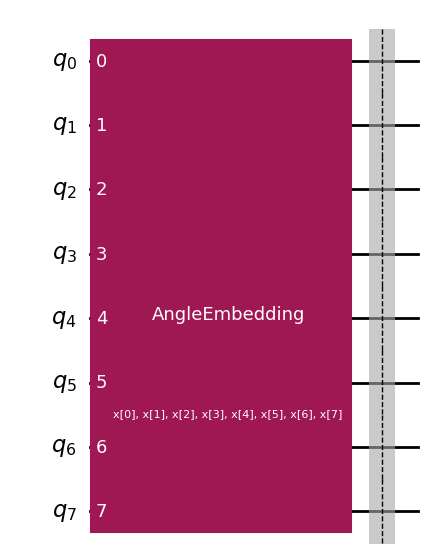

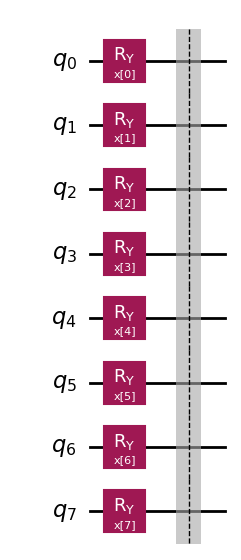

In [26]:
FeatureMap = QCNN_FeatureMap(num_qubits = num_qubits,
                             embed_method = embed_method)
print("FeatureMap name:", FeatureMap.name)
print("FeatureMap parameters:", FeatureMap.parameters)
print("object type:", type(FeatureMap))
display(FeatureMap.draw(output='mpl', style=circ_style))
display(FeatureMap.decompose().draw('mpl'))

Ansatz name: QCNN_Ansatz_X
Ansatz parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])
object type: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


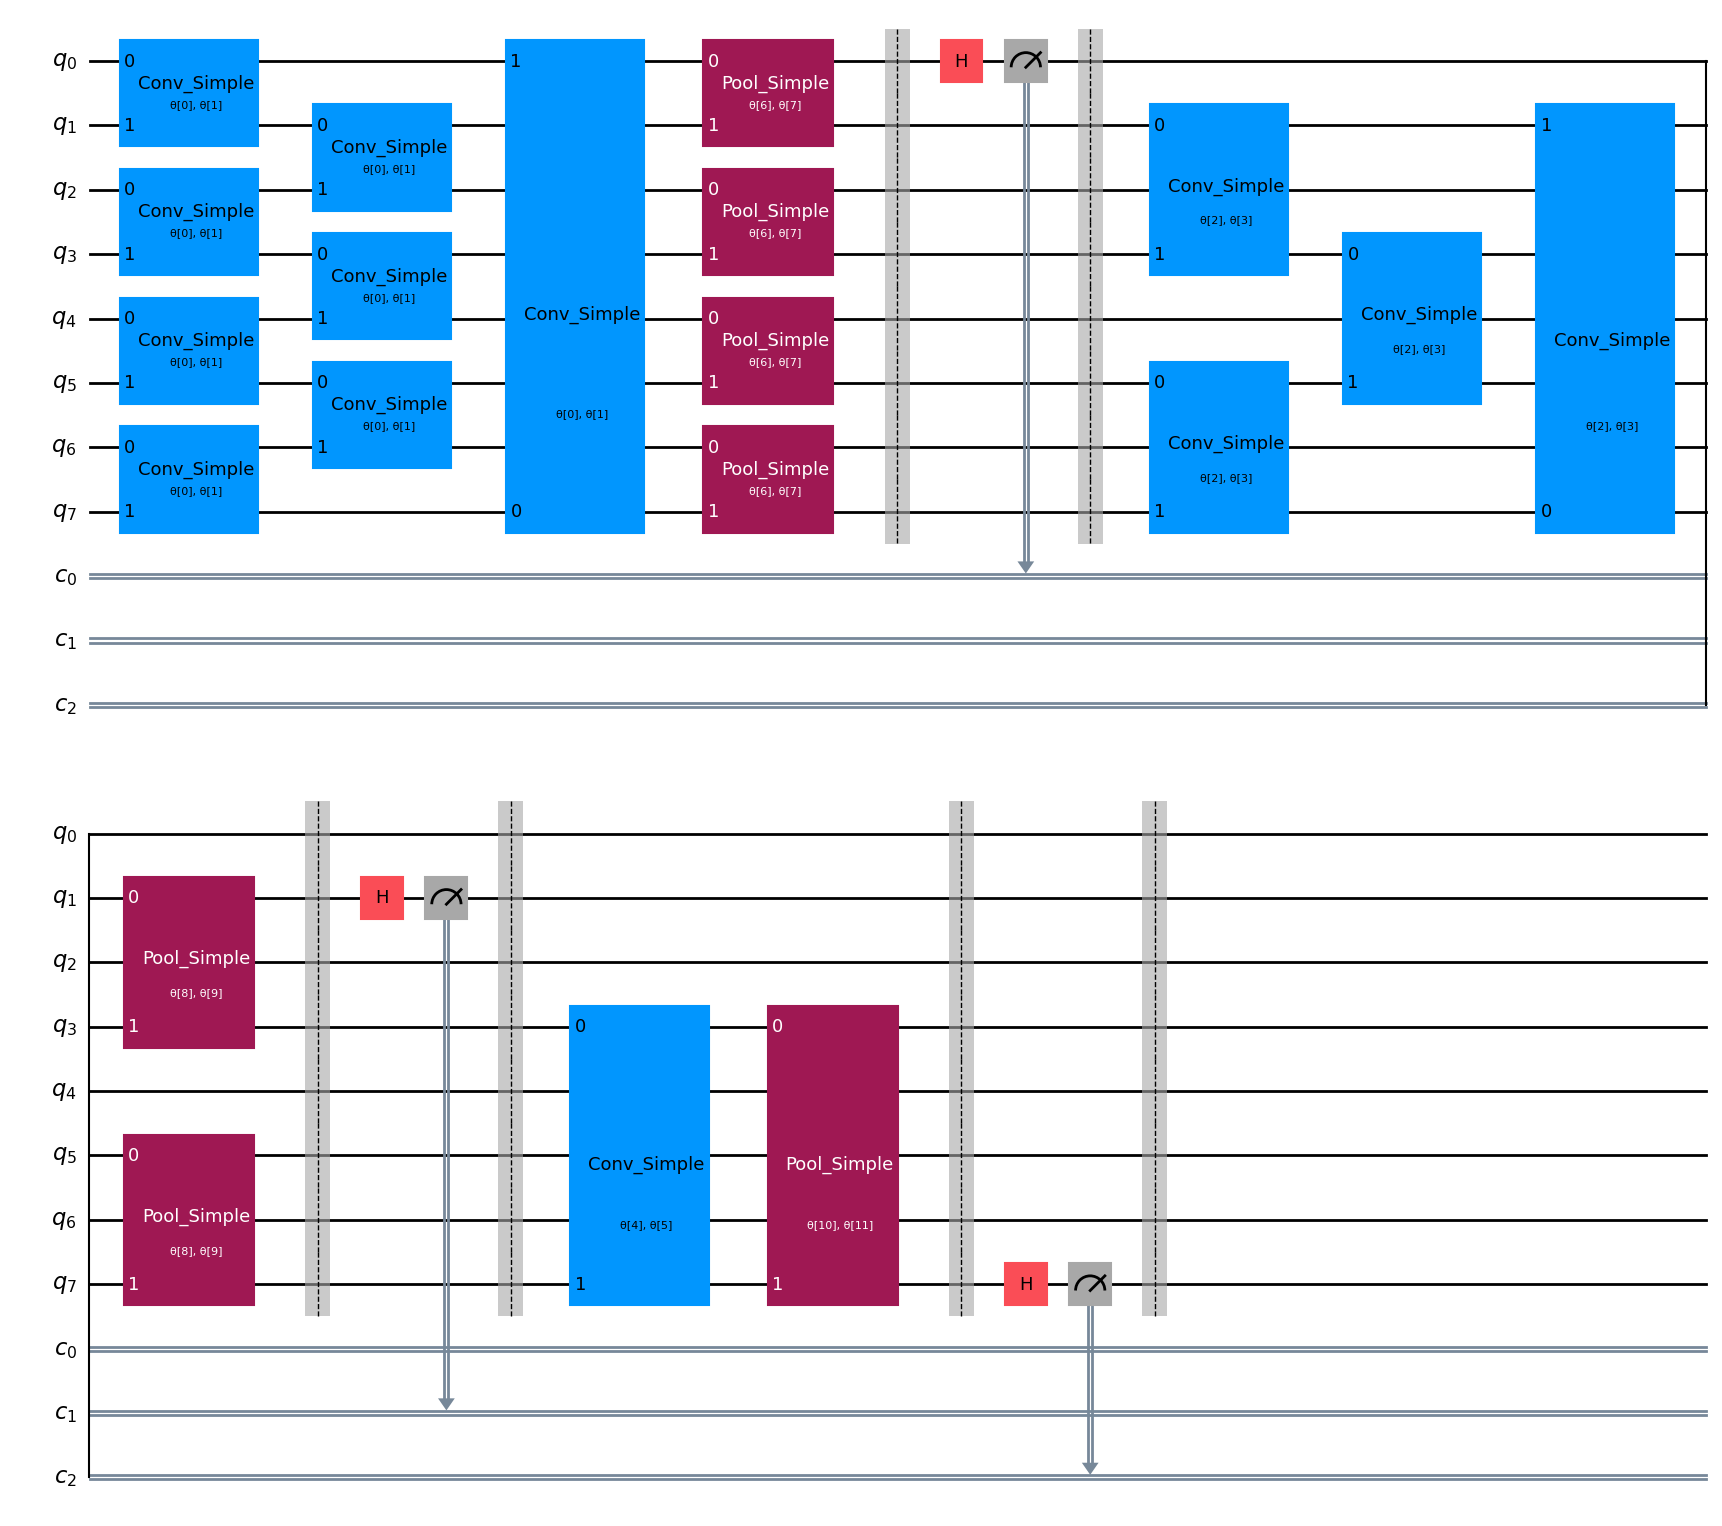

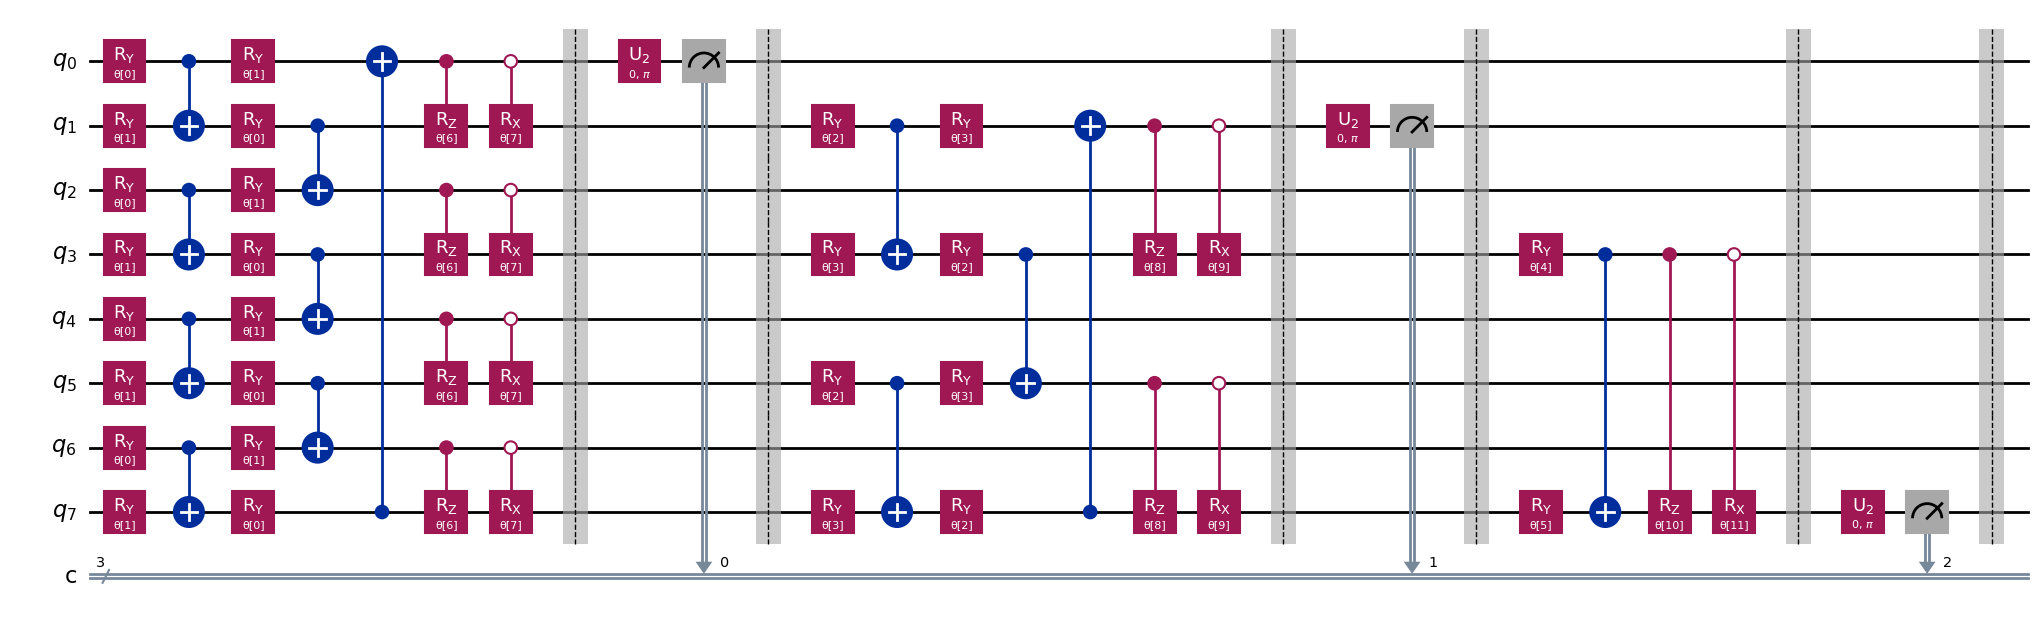

Ansatz name: QCNN_Ansatz_Y
Ansatz parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])
object type: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


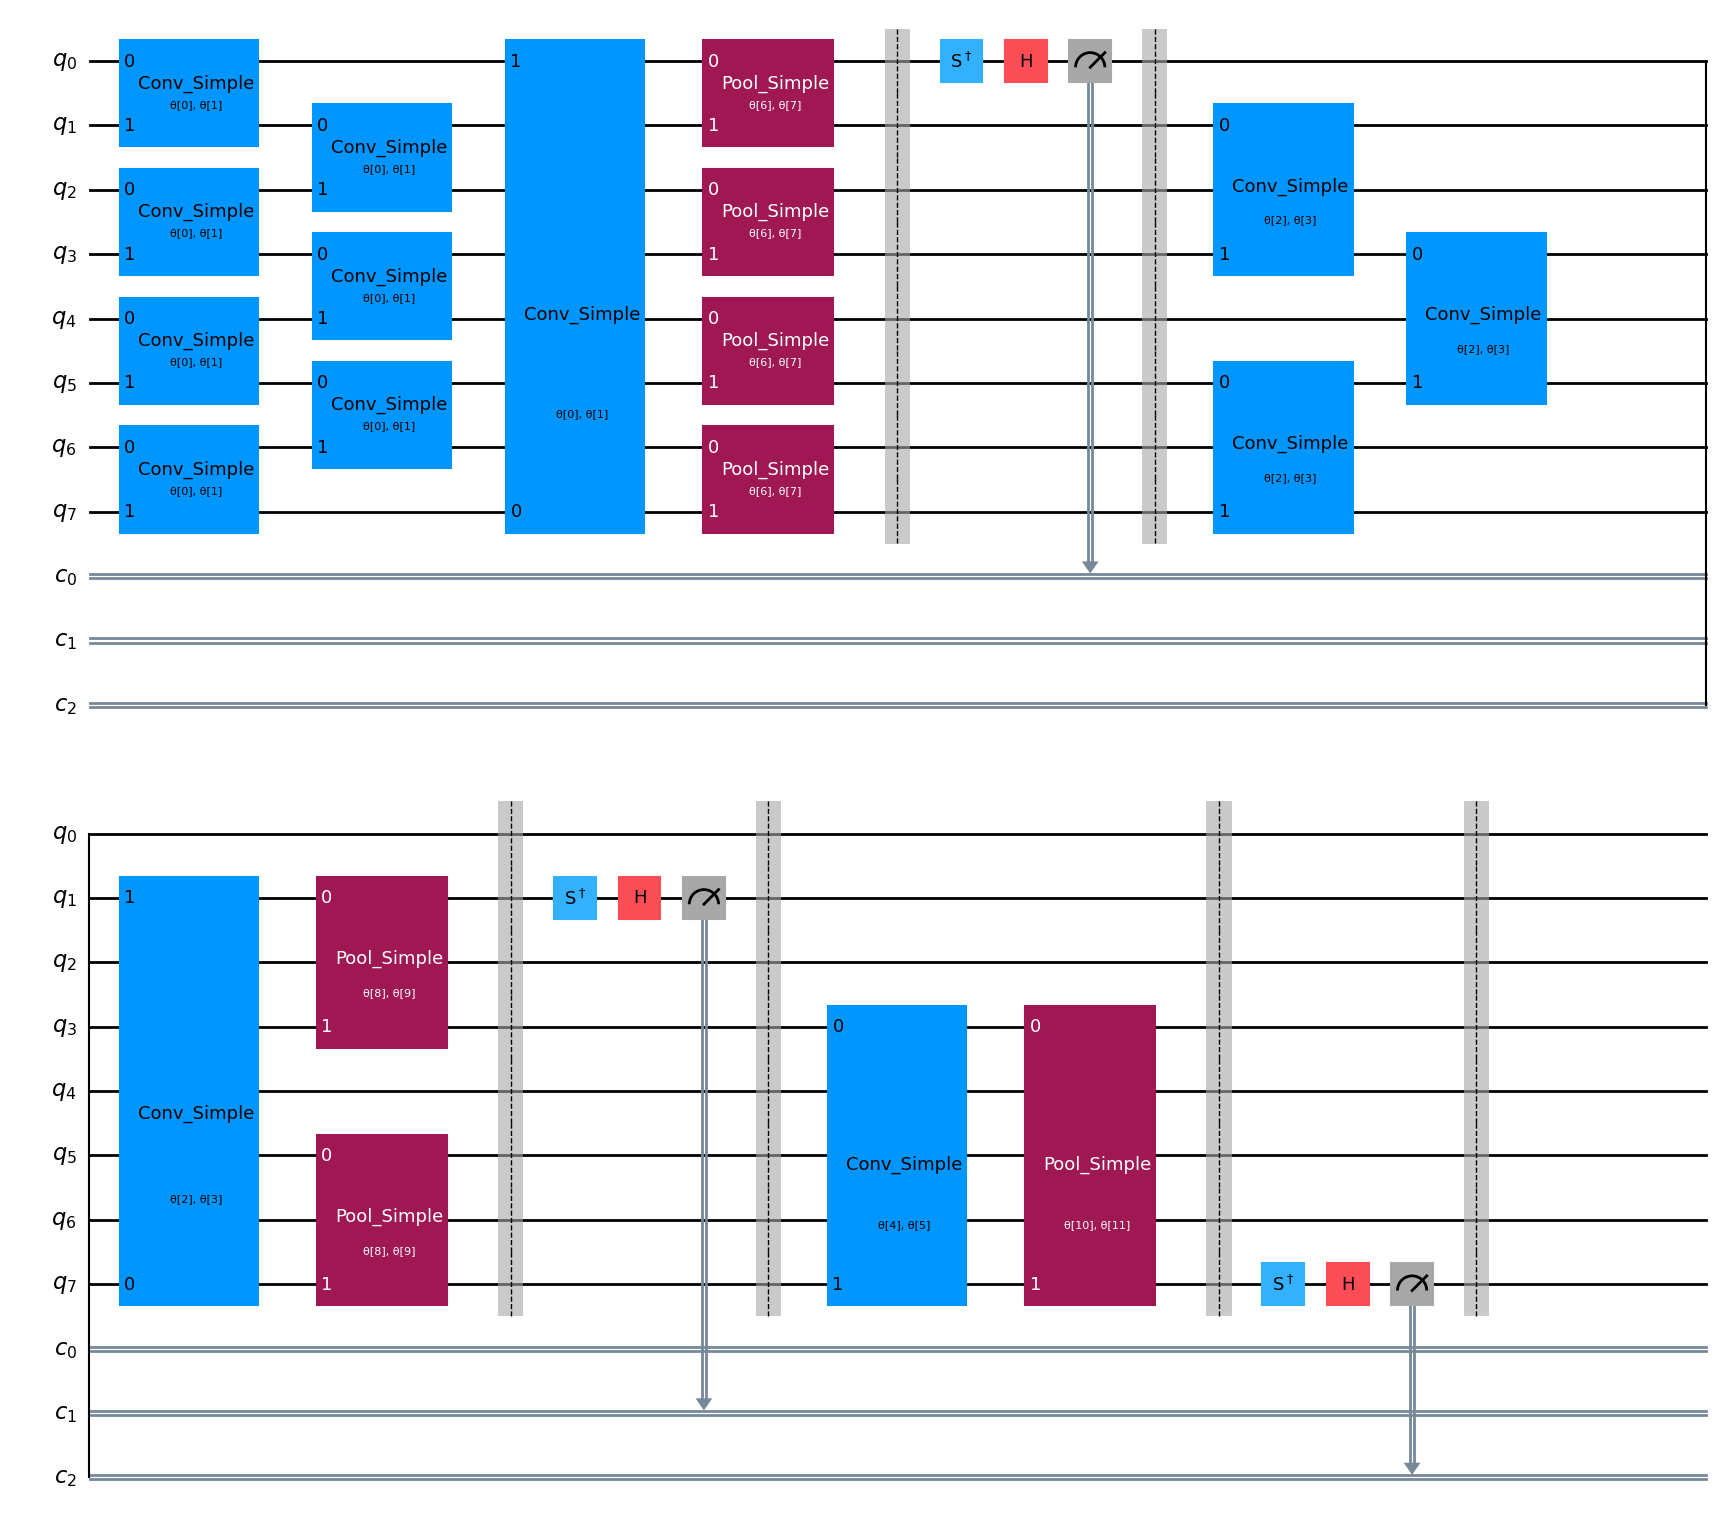

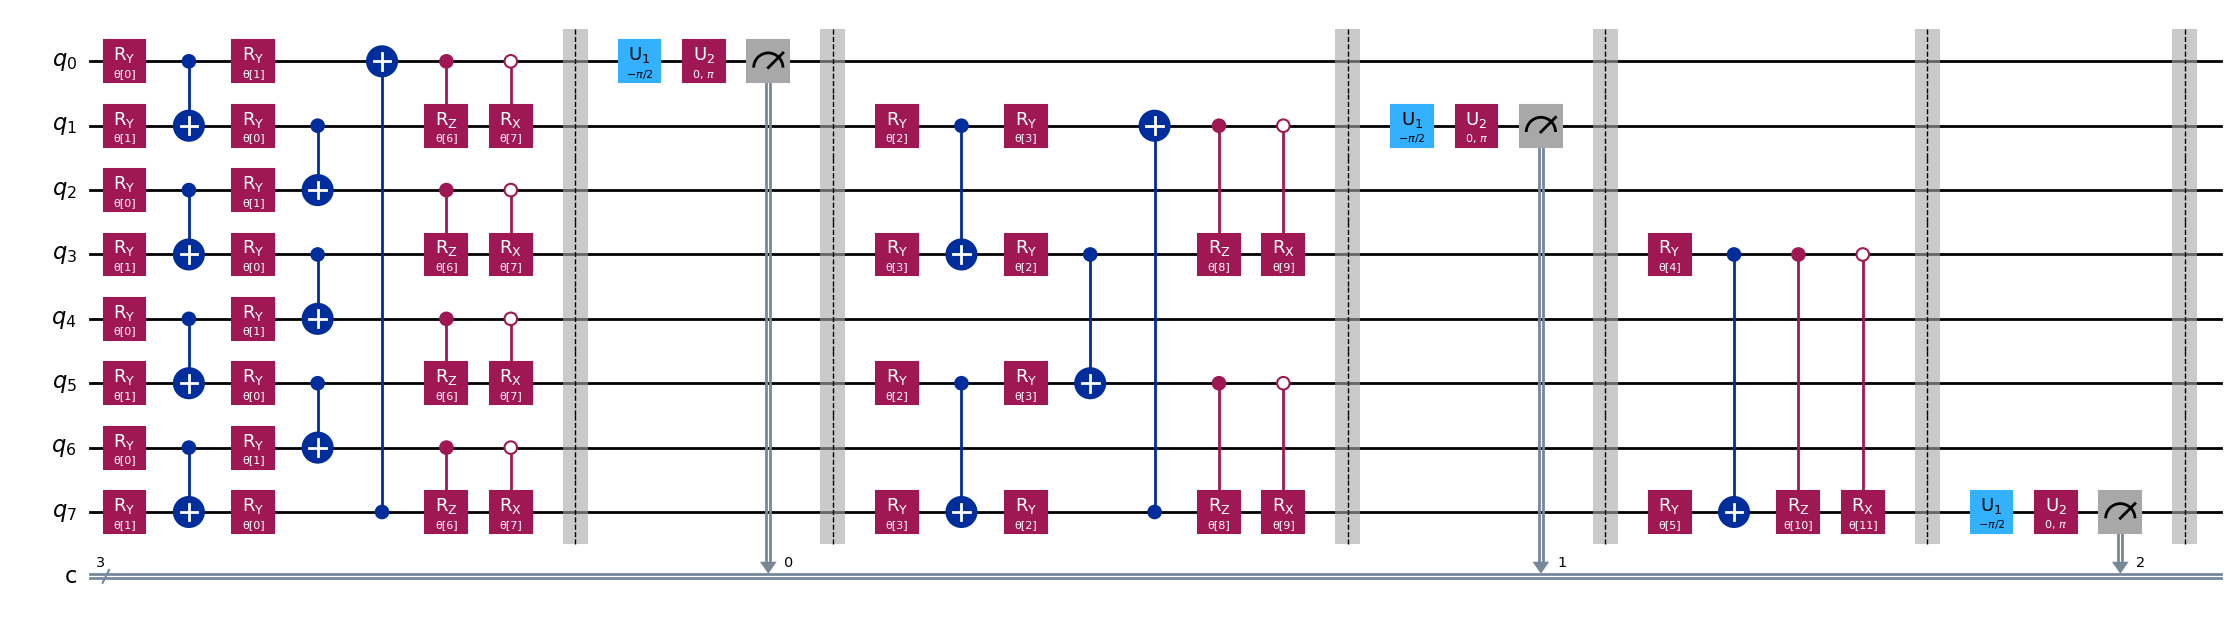

Ansatz name: QCNN_Ansatz_Z
Ansatz parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])
object type: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


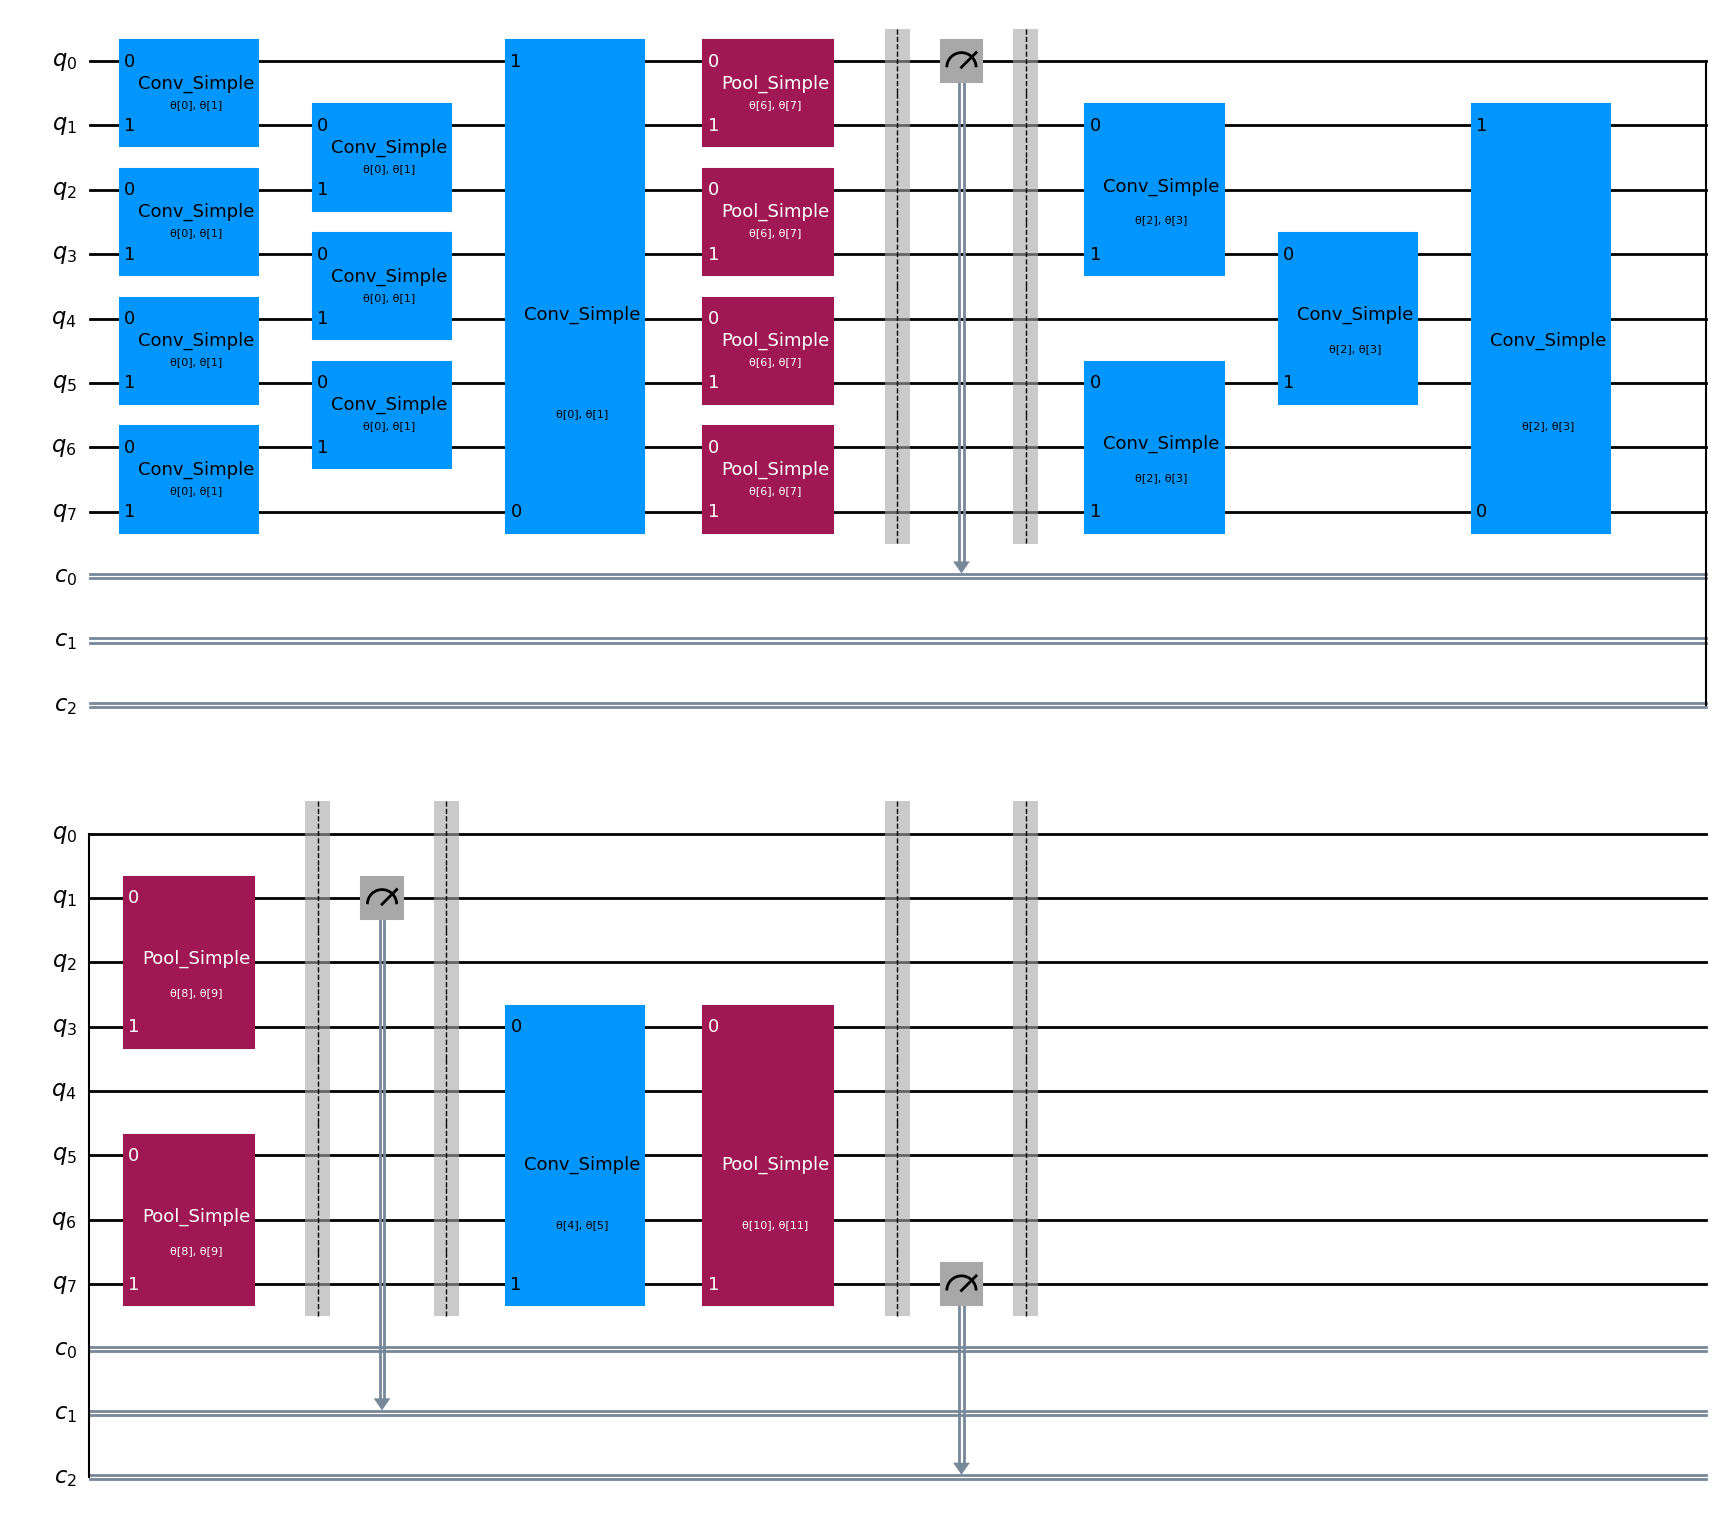

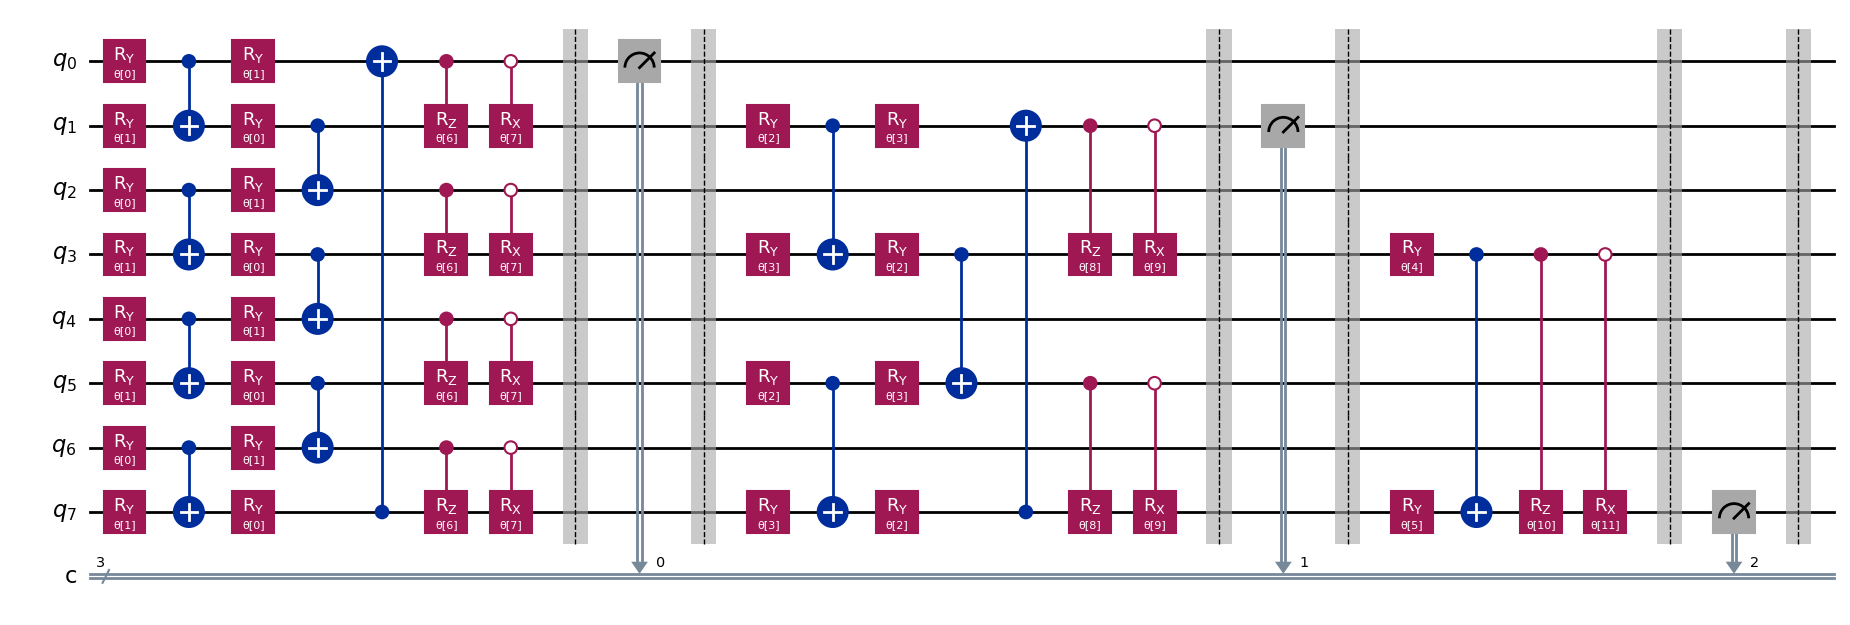

In [27]:
Ansatz_list = QCNN_Ansatz_list(num_qubits = num_qubits,
                               conv_block = conv_block,
                               pool_block = pool_block,
                               multi_meas = multi_meas,
                               multi_basis = multi_basis,
                               no_boundary = NO_BOUNDARY)

for j in range(len(Ansatz_list)):
    print("Ansatz name:", Ansatz_list[j].name)
    print("Ansatz parameters:", Ansatz_list[j].parameters)
    print("object type:", type(Ansatz_list[j]))
    display(Ansatz_list[j].draw(output='mpl', style=circ_style, cregbundle = False))
    display(Ansatz_list[j].decompose(reps=1).draw('mpl', style=circ_style, fold=100))

circuit name: QCNN_circ_mmTmbT_X
circuit parameters:
  input parameters: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3]), ParameterVectorElement(x[4]), ParameterVectorElement(x[5]), ParameterVectorElement(x[6]), ParameterVectorElement(x[7])])
  weight parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])
object type: <class 'qiskit_machine_learning.circuit.library.qnn_circuit.QNNCircuit'>


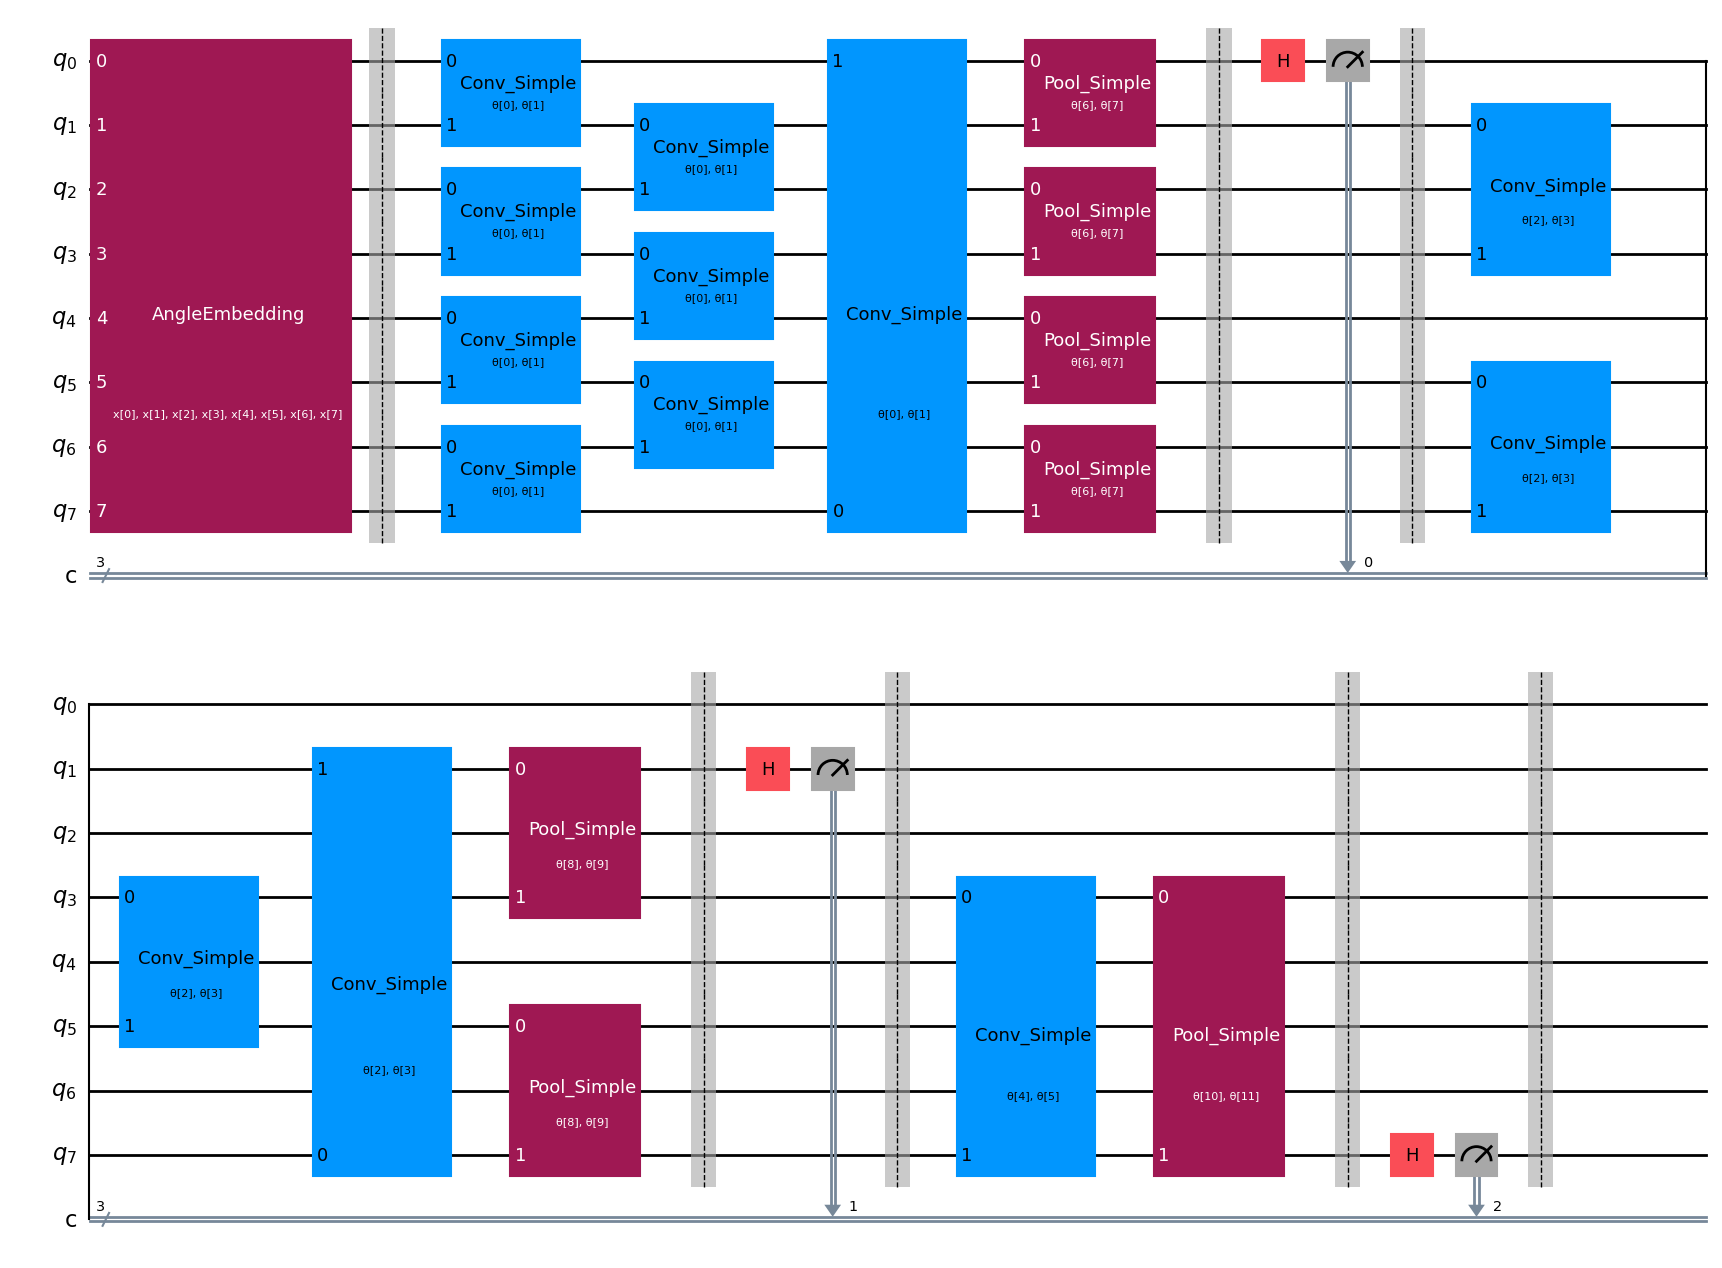

circuit name: QCNN_circ_mmTmbT_Y
circuit parameters:
  input parameters: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3]), ParameterVectorElement(x[4]), ParameterVectorElement(x[5]), ParameterVectorElement(x[6]), ParameterVectorElement(x[7])])
  weight parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])
object type: <class 'qiskit_machine_learning.circuit.library.qnn_circuit.QNNCircuit'>


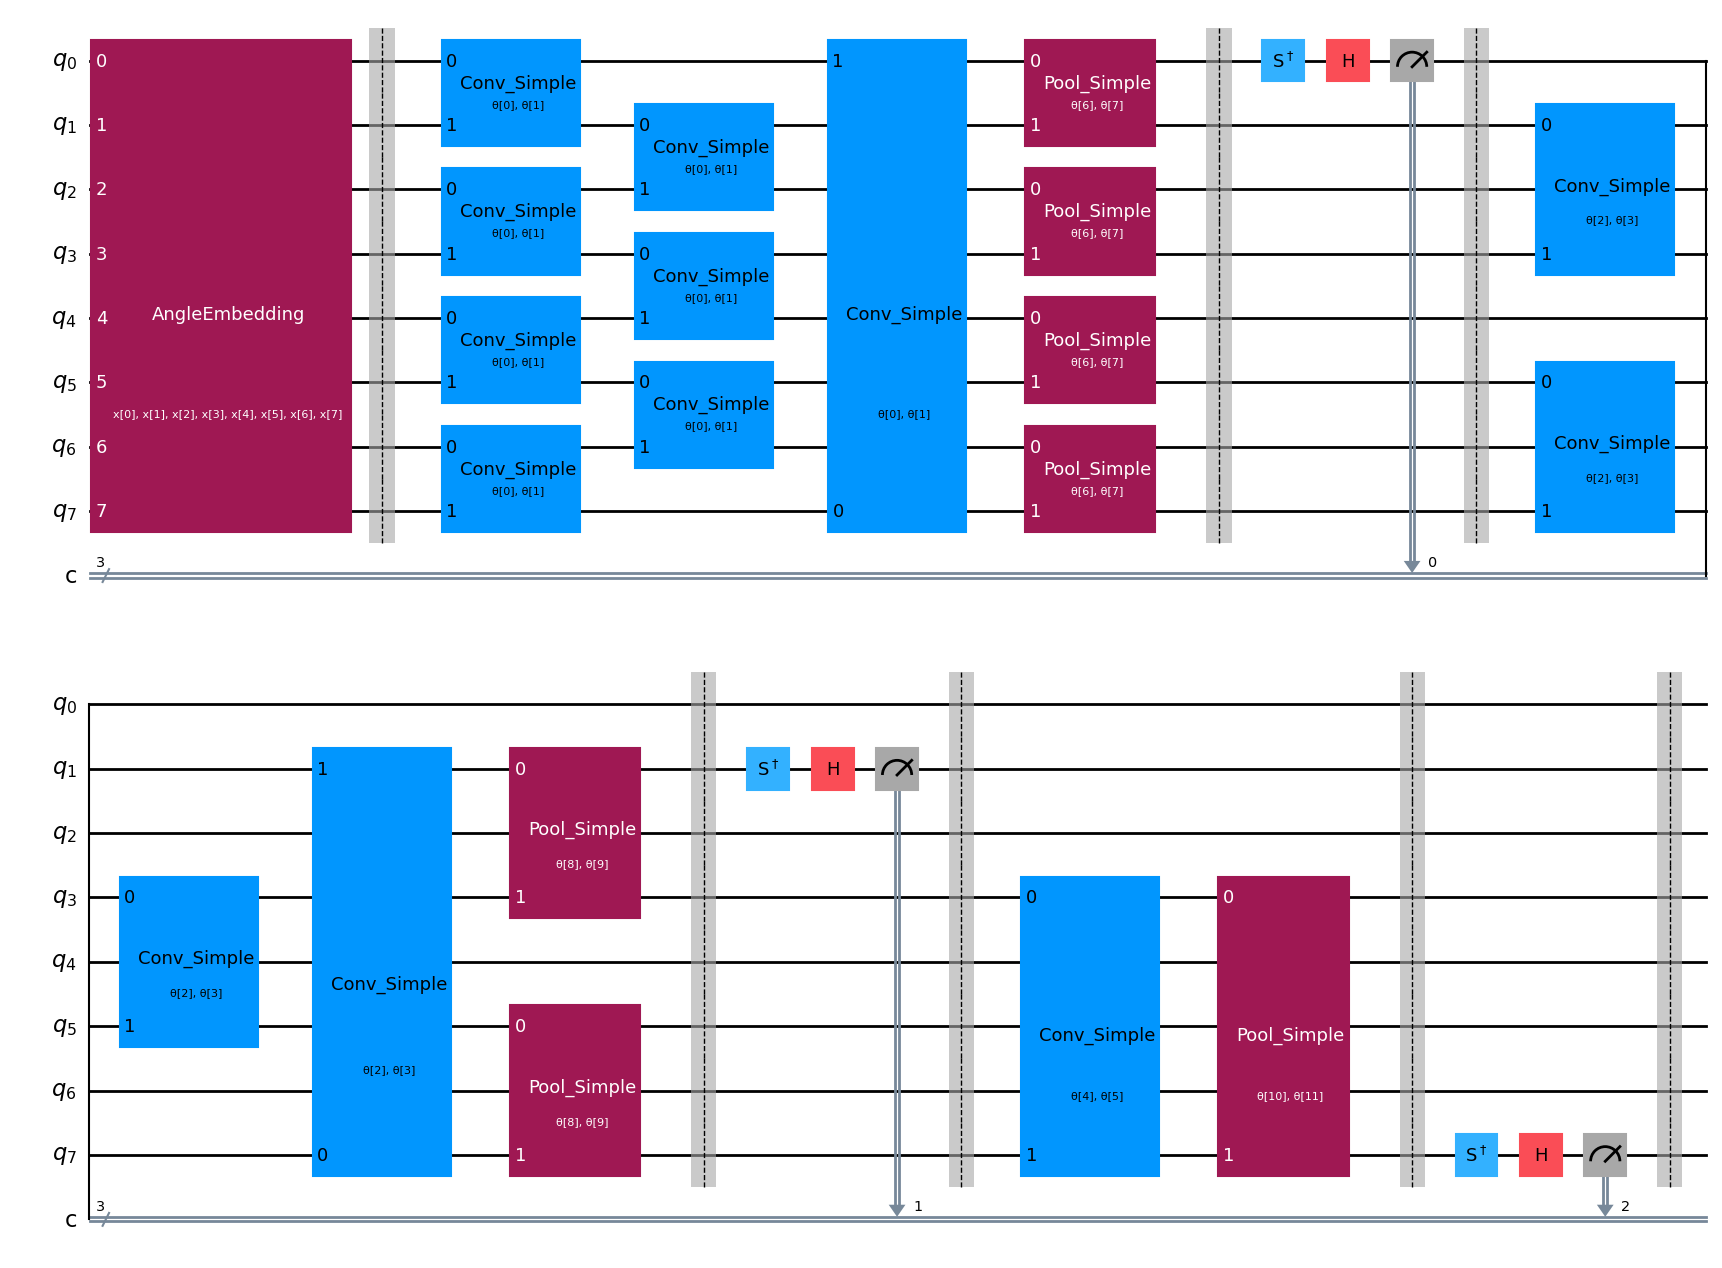

circuit name: QCNN_circ_mmTmbT_Z
circuit parameters:
  input parameters: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3]), ParameterVectorElement(x[4]), ParameterVectorElement(x[5]), ParameterVectorElement(x[6]), ParameterVectorElement(x[7])])
  weight parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11])])
object type: <class 'qiskit_machine_learning.circuit.library.qnn_circuit.QNNCircuit'>


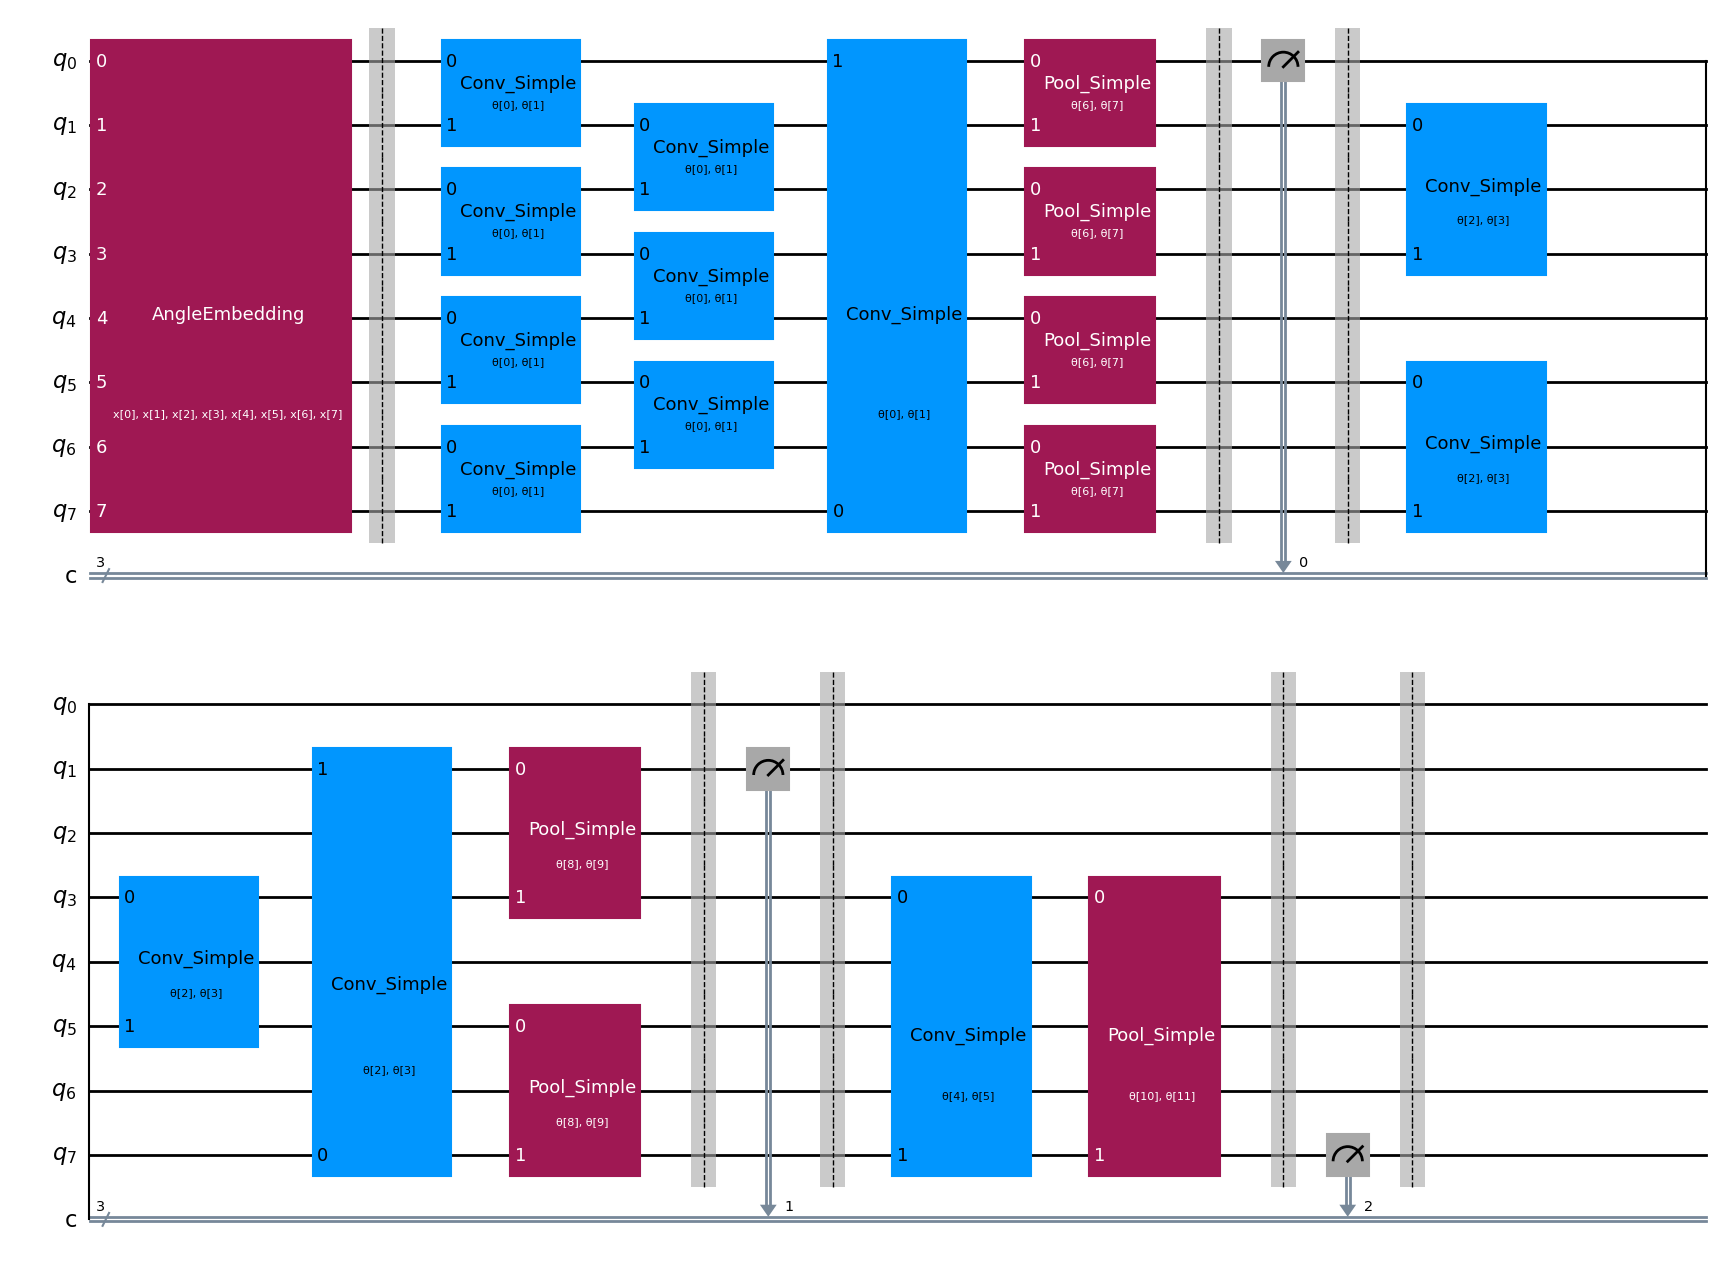

In [28]:
# Plot the QCNN circuit and save it.
SAVE_PLOT_CIRCUIT = False
num_reps = 0    # num_reps = 0, 2

if SAVE_PLOT_CIRCUIT == True:
    # Create the folder if it doesn't exist
    import os
    save_dir_plot = save_dir + 'circuit_plots/'
    if not os.path.exists(save_dir_plot):
        os.makedirs(save_dir_plot)

QCNN_circ = QCNN_full_circuit(num_qubits = num_qubits,
                              feature_map = FeatureMap,
                              ansatz_list = Ansatz_list,
                              multi_meas = multi_meas,
                              multi_basis = multi_basis)

for j in range(len(QCNN_circ)):
    print("circuit name:", QCNN_circ[j].name)
    # print("circuit parameters:", QCNN_circ[j].parameters)
    print("circuit parameters:")
    print("  input parameters:", QCNN_circ[j].input_parameters)
    print("  weight parameters:", QCNN_circ[j].weight_parameters)
    print("object type:", type(QCNN_circ[j]))
    display(QCNN_circ[j].decompose(reps=num_reps).draw('mpl', style=circ_style, fold=25))
    if SAVE_PLOT_CIRCUIT == True:
        plot_savefile = save_dir_plot + f'{QCNN_circ[j].name}_{conv_block}_{pool_block}{NO_BOUNDARY_str}_decomp{num_reps}.png'
        QCNN_circ[j].decompose(reps=num_reps).draw('mpl', style=circ_style, fold=40, cregbundle = False).savefig(plot_savefile, dpi=100, bbox_inches='tight')

In [29]:
# Decompose circuit to avoid any miscellaneous errors
for k in range(len(QCNN_circ)):
    QCNN_circ[k] = QCNN_circ[k].decompose(reps=1)

### Transpile circuit, Sampler, and SamplerQNN

In [30]:
# from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_ibm_runtime import Session, Batch, SamplerV2, EstimatorV2, SamplerOptions
from qiskit.primitives import BaseSamplerV2, BackendSamplerV2, BackendEstimatorV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient, ParamShiftEstimatorGradient, SPSAEstimatorGradient
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
# from qiskit_machine_learning.connectors import TorchConnector


# interpret function of SamplerQNN
def null_interpret(x):
    # To define `output_shape` we must also define an `interpret` function,
    # even if it do nothing. If `output_shape` is not defined, the measurement
    # will always return an array with 2^n quasi-probabilities, padding with
    # zeroes the amplitudes not associated with measured qubits.
    return x

def qiskit_session_sampler_pm_gradient_SamplerQNN(noise_setting, backend,
                                                  multi_basis, QCNN_circ, FeatureMap, Ansatz_list,
                                                  num_meas_for_each_circ,
                                                  num_shots = 1024):
    # Session
    session = Session(backend = backend)
    # session = Batch(backend = backend)
    
    # Sampler, Pass manager
    if noise_setting == '0':
        sampler = SamplerV2(mode = backend)
        # estimator = EstimatorV2(mode = backend)
        pass_manager = None
    elif noise_setting in ['1', '2', '3']:
        # sampler = SamplerV2(mode = backend)
        # sampler = SamplerV2(mode = session)
        
        # options.execution.shots = num_shots
        # sampler = BackendSamplerV2(backend = backend, options = options)
        sampler = BackendSamplerV2(backend = backend, options = {"default_shots": num_shots})
        pass_manager = generate_preset_pass_manager(optimization_level = 1, backend = backend)
    # elif noise_setting == '3':
    #     # sampler = SamplerV2(mode = backend)
    #     options = SamplerOptions(default_shots = num_shots)
    #     sampler = SamplerV2(mode = session, options = options)
    #     pass_manager = generate_preset_pass_manager(optimization_level = 1, backend = backend)
        
    # Gradient
    sampler_gradient = ParamShiftSamplerGradient(sampler = sampler, pass_manager = pass_manager)
    # sampler_gradient = SPSASamplerGradient(sampler = sampler, pass_manager = pass_manager)
    
    if multi_basis == False:        
        # SamplerQNN
        qcnn_qnn = SamplerQNN(
            circuit = QCNN_circ[0],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[0].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        
        # QNN list
        qnn_list = [qcnn_qnn]
        
    else:
        # SamplerQNN
        qcnn_qnn_X = SamplerQNN(
            circuit = QCNN_circ[0],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[0].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        qcnn_qnn_Y = SamplerQNN(
            circuit = QCNN_circ[1],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[1].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        qcnn_qnn_Z = SamplerQNN(
            circuit = QCNN_circ[2],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[2].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        
        # QNN list
        qnn_list = [qcnn_qnn_X, qcnn_qnn_Y, qcnn_qnn_Z]
        
    return session, sampler, qnn_list

# if noise_setting != '3':
session, sampler, qnn_list = qiskit_session_sampler_pm_gradient_SamplerQNN(
    noise_setting = noise_setting,
    backend = backend,
    multi_basis = multi_basis,
    QCNN_circ = QCNN_circ,
    FeatureMap = FeatureMap,
    Ansatz_list = Ansatz_list,
    num_meas_for_each_circ = num_meas_for_each_circ,
    num_shots = num_shots
    )

In [31]:
# display(qcnn_qnn_X.circuit.draw('mpl'))

# from qiskit_machine_learning.connectors import TorchConnector
# TorchConnector(qcnn_qnn_X, initial_weights = weights)(X_train_pca.data[0])

## Build Classical Neural Network using PyTorch module

### NN MODEL HYPERPARAMETERS TO CHANGE

In [32]:
# Define the number of epochs, batch size, activation function for the hidden layers and the output layer
import math
from torch.nn import Identity, ReLU, CELU, Sigmoid, Tanh

num_epochs = 30
batch_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)

hidden_acti = ReLU()    # torch.nn.Identity, ReLU, CELU, Sigmoid, Tanh
output_acti = Tanh()    # torch.nn.Tanh

# Set the optimizer's learning rate and lr_schedule
lr_value = 0.01
lr_schedule = False
lr_schedule_str = '_schedT' if lr_schedule else ""

# Define the input size and layer size
input_size = num_meas_total
output_size = 1
layer_sizes = None if input_size == 1 else (input_size, 3 * input_size, output_size)
# layer_sizes = None if input_size == 1 else (input_size, 3 * input_size, 3 * input_size, output_size)
num_hidden_layers = len((input_size, 3 * input_size, output_size)) - 2

print('----------Configuration of NN model structure and optimization setting----------')
print('num_epochs:', num_epochs)
print('batch_size:', batch_size)
print('batch_per_epoch:', batch_per_epoch)
print('lr_value:', lr_value)
print('hidden_acti:', hidden_acti)
print('output_acti:', output_acti)
print()
print('input_size:', input_size)
print('layer_sizes:', layer_sizes)
print('num_hidden_layers:', num_hidden_layers)

----------Configuration of NN model structure and optimization setting----------
num_epochs: 30
batch_size: 10
batch_per_epoch: 10
lr_value: 0.01
hidden_acti: ReLU()
output_acti: Tanh()

input_size: 9
layer_sizes: (9, 27, 1)
num_hidden_layers: 1


In [33]:
from torch import concat, sum as tsum

def get_counts(x, num_measurements):
    # Calculates the probability of measuring zero on each qubit
    # separately from the measurement probability vector.
    if x.dim() == 1:  # Add batch dimension if missing
        x = x.unsqueeze(0)
        
    #size = 2**(3 * num_measurements)
    size = 2**(num_measurements)

    idx = [v for i, v in enumerate(range(size)) if i % 2 < 1]
    new_x = tsum(x[:,idx], 1, True)

    #for bit in range(1, 3 * num_measurements):
    for bit in range(1, num_measurements):
        idx = [v for i, v in enumerate(range(size)) if i % 2**(bit+1) < 2**bit]
        new_x = concat([new_x, tsum(x[:,idx], 1, True)], 1)

    return new_x

In [34]:
# Define quantum-classical hybrid neural network model
import torch
import torch.nn as nn
from qiskit_machine_learning.connectors import TorchConnector

# Define torch NN module
class QC_Hybrid_Net(nn.Module):
    def __init__(self, qnn_list,
                 layer_sizes, hidden_acti, output_acti,
                 multi_meas = False, multi_basis = False,
                 num_meas_for_each_circ = num_meas_for_each_circ):
        super().__init__()
        self.multi_meas = multi_meas
        self.multi_basis = multi_basis
        self.num_meas_for_each_circ = num_meas_for_each_circ
        
        # Define quantum layer
        # self.q_layer = TorchConnector(qcnn_qnn)
        if self.multi_meas == False:
            self.qlayer_trad = TorchConnector(qnn_list[0])
        elif (self.multi_meas, self.multi_basis) == (True, False):
            self.qlayer_Z = TorchConnector(qnn_list[0])
        elif (self.multi_meas, self.multi_basis) == (True, True):
            self.qlayer_X = TorchConnector(qnn_list[0])
            self.qlayer_Y = TorchConnector(qnn_list[1])
            self.qlayer_Z = TorchConnector(qnn_list[2])
            
            # Share the parameters between qlayer_X, qlayer_Y, and qlayer_Z
            self._share_weights(self.qlayer_X, self.qlayer_Y, self.qlayer_Z)
        
        # Define classical layers
        if self.multi_meas == True:
            self.hidden_acti = hidden_acti
            self.output_acti = output_acti
            layers = []
            for i in range(len(layer_sizes) - 2):
                layers.append(nn.Linear(in_features = layer_sizes[i],
                                        out_features = layer_sizes[i + 1]))
                layers.append(self.hidden_acti)
            layers.append(nn.Linear(in_features = layer_sizes[-2],
                                    out_features = layer_sizes[-1]))
            layers.append(self.output_acti)
            self.linear_stack = nn.Sequential(*layers)
                   
    def forward(self, x):
        if self.multi_meas == False:
            # x = self.qlayer_trad(x)
            x = get_counts(self.qlayer_trad(x), num_measurements = 1)
        elif (self.multi_meas, self.multi_basis) == (True, False):
            x = get_counts(self.qlayer_Z(x), num_measurements = self.num_meas_for_each_circ)
            x = self.linear_stack(x)
        elif (self.multi_meas, self.multi_basis) == (True, True):
            x1 = get_counts(self.qlayer_X(x), num_measurements = self.num_meas_for_each_circ)
            x2 = get_counts(self.qlayer_Y(x), num_measurements = self.num_meas_for_each_circ)
            x3 = get_counts(self.qlayer_Z(x), num_measurements = self.num_meas_for_each_circ)
            x = torch.cat([x1, x2, x3], axis = 1)
            x = self.linear_stack(x)
        return x.reshape(-1)

    
    def _share_weights(self, *layers):
        """Ensure all given quantum layers share the same _parameters dictionary."""
        shared_params = layers[0]._parameters  # Get the _parameters of the first layer
        for layer in layers[1:]:
            layer._parameters = shared_params  # Assign the same _parameters dictionary

    
    def check_shared_parameters(self):
        """Verify that qlayer_X, qlayer_Y, and qlayer_Z share parameters and have identical values."""
        if self.multi_meas and self.multi_basis:
            print("Checking if parameters are shared:")

            # Compare qlayer_X and qlayer_Y
            shared_XY = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_X.parameters(), self.qlayer_Y.parameters())
            )
            print(f"qlayer_X and qlayer_Y shared: {shared_XY}")

            # Compare qlayer_Y and qlayer_Z
            shared_YZ = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_Y.parameters(), self.qlayer_Z.parameters())
            )
            print(f"qlayer_Y and qlayer_Z shared: {shared_YZ}")

            # Compare qlayer_Z and qlayer_X
            shared_ZX = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_Z.parameters(), self.qlayer_X.parameters())
            )
            print(f"qlayer_Z and qlayer_X shared: {shared_ZX}")

            print("\nChecking if parameter values are identical:")

            # Check if parameter values are identical
            values_XY = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_X.parameters(), self.qlayer_Y.parameters())
            )
            print(f"qlayer_X and qlayer_Y values identical: {values_XY}")

            values_YZ = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_Y.parameters(), self.qlayer_Z.parameters())
            )
            print(f"qlayer_Y and qlayer_Z values identical: {values_YZ}")

            values_ZX = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_Z.parameters(), self.qlayer_X.parameters())
            )
            print(f"qlayer_Z and qlayer_X values identical: {values_ZX}")

        else:
            print("This model doesn't use shared parameters.")

In [35]:
# Instantiate the model for training and evaluation (on test data)
# if noise_setting != '3':
model = QC_Hybrid_Net(
    qnn_list = qnn_list,
    layer_sizes = layer_sizes,
    hidden_acti = hidden_acti,
    output_acti = output_acti,
    multi_meas = multi_meas,
    multi_basis = multi_basis)
model_eval = QC_Hybrid_Net(
    qnn_list = qnn_list,
    layer_sizes = layer_sizes,
    hidden_acti = hidden_acti,
    output_acti = output_acti,
    multi_meas = multi_meas,
    multi_basis = multi_basis)

model

QC_Hybrid_Net(
  (qlayer_X): TorchConnector()
  (qlayer_Y): TorchConnector()
  (qlayer_Z): TorchConnector()
  (hidden_acti): ReLU()
  (output_acti): Tanh()
  (linear_stack): Sequential(
    (0): Linear(in_features=9, out_features=27, bias=True)
    (1): ReLU()
    (2): Linear(in_features=27, out_features=1, bias=True)
    (3): Tanh()
  )
)

In [36]:
model.parameters

<bound method Module.parameters of QC_Hybrid_Net(
  (qlayer_X): TorchConnector()
  (qlayer_Y): TorchConnector()
  (qlayer_Z): TorchConnector()
  (hidden_acti): ReLU()
  (output_acti): Tanh()
  (linear_stack): Sequential(
    (0): Linear(in_features=9, out_features=27, bias=True)
    (1): ReLU()
    (2): Linear(in_features=27, out_features=1, bias=True)
    (3): Tanh()
  )
)>

In [37]:
# if noise_setting != '3':
# print(model(X_train.data[0]))
print(model(X_train_tensor[0]))
if (multi_meas, multi_basis) == (True, True):
    model.check_shared_parameters()

tensor([-0.2568317056], grad_fn=<ViewBackward0>)
Checking if parameters are shared:
qlayer_X and qlayer_Y shared: True
qlayer_Y and qlayer_Z shared: True
qlayer_Z and qlayer_X shared: True

Checking if parameter values are identical:
qlayer_X and qlayer_Y values identical: True
qlayer_Y and qlayer_Z values identical: True
qlayer_Z and qlayer_X values identical: True


## Training the model

### NN MODEL OPTIMIZERS TO CHANGE

In [38]:
# Define model, optimizer, and loss function
from torch.nn import BCELoss, CrossEntropyLoss, MSELoss, NLLLoss
from torch.optim.lr_scheduler import StepLR, MultiStepLR

# Optimizer
def optimizer_lrscheduler(model, lr_value, lr_schedule = False,
                          step_size = None, gamma = None, milestone = None):
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr = lr_value,
                                 betas = (0.9, 0.999),
                                 eps = 1e-08,
                                 weight_decay = 0)
    # Learning Rate scheduler
    if lr_schedule:
        # gamma = 0.1
        # step_size = int(num_epochs*0.5)
        lr_scheduler = StepLR(optimizer, step_size = step_size, gamma = gamma)
        print(f"Learning rate scheduler initialized with step_size={step_size}, gamma={gamma}.")
        
        # milestone = [int(num_epochs*(1/3)), int(num_epochs*(2/3))]
        # lr_scheduler = MultiStepLR(optimizer, milestones = milestone, gamma = gamma)
        # print(f"Learning rate scheduler initialized with gamma = {gamma}.")
        # print('lr_scheduler.milestones:', lr_scheduler.milestones)
    else:
        lr_scheduler = None
        print("Learning rate scheduler is disabled.")
        
    return optimizer, lr_scheduler

# if noise_setting != '3':
if lr_schedule:
    gamma = 0.1
    step_size = int(num_epochs*(0.5))
    milestone = [int(num_epochs*(1/3)), int(num_epochs*(2/3))]
else:
    gamma = None
    step_size = None
    
optimizer, lr_scheduler = optimizer_lrscheduler(
    model = model,
    lr_value = lr_value,
    lr_schedule = lr_schedule,
    step_size = step_size,
    gamma = gamma
    )
print('optimizer:', optimizer.__class__.__name__)
print('Initial lr_value:', lr_value)

# Loss function
loss_func = MSELoss()   # BCELoss(), CrossEntropyLoss, MSELoss()
print('loss_func:', loss_func.__class__.__name__)

Learning rate scheduler is disabled.
optimizer: Adam
Initial lr_value: 0.01
loss_func: MSELoss


In [39]:
# if noise_setting != '3':
# Check model parameters
print("Model Parameters:")
for name, param in model.named_parameters():
    print(f"Name: {name}, Shape: {param.shape}, Requires Grad: {param.requires_grad}")

# Check parameter count consistency
num_model_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_optimizer_params = sum(p.numel() for p in optimizer.param_groups[0]['params'])
print(f"\nNumber of trainable parameters in model: {num_model_params}")
print(f"Number of parameters in optimizer: {num_optimizer_params}")
assert num_model_params == num_optimizer_params, "Parameter mismatch between model and optimizer!"

# Verify loss function and learning rate scheduler
print(f"\nLoss Function: {loss_func.__class__.__name__}")
if lr_scheduler:
    print(f"Learning Rate Scheduler: Step Size = {step_size}, Gamma = {gamma}")
else:
    print("Learning Rate Scheduler: Disabled")

Model Parameters:
Name: qlayer_X.weight, Shape: torch.Size([12]), Requires Grad: True
Name: linear_stack.0.weight, Shape: torch.Size([27, 9]), Requires Grad: True
Name: linear_stack.0.bias, Shape: torch.Size([27]), Requires Grad: True
Name: linear_stack.2.weight, Shape: torch.Size([1, 27]), Requires Grad: True
Name: linear_stack.2.bias, Shape: torch.Size([1]), Requires Grad: True

Number of trainable parameters in model: 310
Number of parameters in optimizer: 310

Loss Function: MSELoss
Learning Rate Scheduler: Disabled


In [40]:
# if noise_setting != '3':
print("Train Data and Targets:")

for batch, (data, target) in enumerate(train_loader):
    data = data.squeeze()
    target = target.float()
    # target = target.float().unsqueeze(1)
    print('data:', data)
    print('data.shape:', data.shape)
    print('target:', target)
    print('target.shape:', target.shape)
    
    # Pass batch through the model
    output = model(data)  
    print(f"Output: {output}")  # Example output for the batch
    print(f"Target: {target}")  # Example target for the batch

    # Compute loss
    loss = loss_func(output, target)
    print(f"Loss: {loss}")
    
    break  # Remove this line if you want to iterate over all batches

Train Data and Targets:
data: tensor([[1.3423823118, 2.0485939980, 1.4314451218, 0.1135535464, 1.4949874878,
         1.6203138828, 0.2705984712, 1.4842963219],
        [1.3980717659, 0.8718598485, 0.9814009666, 0.9897362590, 2.7650971413,
         2.1845395565, 1.3272362947, 1.8982763290],
        [1.4828243256, 1.1026085615, 1.9613837004, 1.7343995571, 1.3179938793,
         1.4331202507, 1.4744340181, 0.0000000000],
        [2.0175464153, 1.2989829779, 1.5187473297, 0.9753941298, 0.7287440896,
         1.3441686630, 1.3821831942, 2.2182583809],
        [1.5621767044, 1.2011339664, 1.7090278864, 1.0877763033, 1.2911669016,
         1.4510056973, 1.5948746204, 1.1612827778],
        [0.3776342869, 1.0372682810, 1.6000593901, 2.3932557106, 1.8509352207,
         1.6534318924, 2.0234329700, 0.0599535219],
        [1.0763092041, 1.2884848118, 1.7961652279, 2.5364608765, 2.2384743690,
         1.4324498177, 1.1645753384, 1.8450073004],
        [1.2568142414, 1.7582547665, 1.6278747320, 0.

### Create Result Folder - For classical Torch Net results
- This code creates a folder to save our model's results.
- If the folder doesn't exist, it makes one.
    - `save_dir_model`: string. name of the folder to be saved.

In [41]:
import os

# Define the folder name
print('save_dir:', save_dir)
save_dir_model = (f'{save_dir}{model_name_str}/{embed_method}_{conv_block}_{pool_block}{NO_BOUNDARY_str}'
                  +f'_{hidden_acti.__class__.__name__ }_hl{num_hidden_layers}_batch{batch_size}_lr{lr_value}{lr_schedule_str}'
                  +f'/ns{noise_setting}_iter{sim_iter_num}_{num_shots}/')

# Create the folder if it doesn't exist
if not os.path.exists(save_dir_model):
    os.makedirs(save_dir_model)
print('save_dir_model:', save_dir_model)

save_dir: save_results_reg/gen_linear_dataset_mr_w_error_8/
save_dir_model: save_results_reg/gen_linear_dataset_mr_w_error_8/model_mmTmbT/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter0_1024/


### Get SHAP value and its plot
- [SHAP - github link](https://github.com/shap/shap?tab=readme-ov-file)

In [42]:
choose_epoch_num = num_epochs
PLOT_SAVE = False

# File path for the log file
train_result_file = save_dir_model + 'train_results.txt'
train_batch_result_file = save_dir_model + 'train_batch_results.txt'

# Load the file into a pandas DataFrame
import pandas as pd
model_train_results = pd.read_csv(train_result_file)[0:choose_epoch_num]
model_train_batch_results = pd.read_csv(train_batch_result_file)

train_loss = model_train_results['train_loss']
batch_loss = model_train_batch_results['train_batch_loss']

# Load model for evaluation with saved parameters
param_history = torch.load(save_dir_model + f'param_history.pth', weights_only = True)[0:choose_epoch_num]
# model_eval.load_state_dict(param_history[choose_epoch_num - 1])

# # param_best = torch.load(save_dir_model + f'best_model_state.pth', weights_only = True)
# # print('best_epoch:', param_best['best_epoch'])
# # model_eval.load_state_dict(param_best['best_model_state_dict'])

# print(f'---Model Performance on Training Dataset---')
# model_reg_train_eval = model_performance(model_eval, train_dataset, loss_func)

# print(f'-----Model Performance on Test Dataset-----')
# model_reg_test_eval  = model_performance(model_eval, test_dataset, loss_func)

In [43]:
# Define quantum-classical hybrid neural network model
import torch
import torch.nn as nn
from qiskit_machine_learning.connectors import TorchConnector

# Define torch NN module - quantum part
class QC_Hybrid_Net_Q_part(nn.Module):
    def __init__(self, qnn_list,
                 layer_sizes, hidden_acti, output_acti,
                 multi_meas = False, multi_basis = False,
                 num_meas_for_each_circ = num_meas_for_each_circ):
        super().__init__()
        self.multi_meas = multi_meas
        self.multi_basis = multi_basis
        self.num_meas_for_each_circ = num_meas_for_each_circ
        
        # Define quantum layer
        # self.q_layer = TorchConnector(qcnn_qnn)
        if self.multi_meas == False:
            self.qlayer_trad = TorchConnector(qnn_list[0])
        elif (self.multi_meas, self.multi_basis) == (True, False):
            self.qlayer_Z = TorchConnector(qnn_list[0])
        elif (self.multi_meas, self.multi_basis) == (True, True):
            self.qlayer_X = TorchConnector(qnn_list[0])
            self.qlayer_Y = TorchConnector(qnn_list[1])
            self.qlayer_Z = TorchConnector(qnn_list[2])
            
            # Share the parameters between qlayer_X, qlayer_Y, and qlayer_Z
            self._share_weights(self.qlayer_X, self.qlayer_Y, self.qlayer_Z)
           
    def forward(self, x):
        if self.multi_meas == False:
            x = get_counts(self.qlayer_trad(x), num_measurements=1)
        elif (self.multi_meas, self.multi_basis) == (True, False):
            x = get_counts(self.qlayer_Z(x), num_measurements=self.num_meas_for_each_circ)
        elif (self.multi_meas, self.multi_basis) == (True, True):
            x1 = get_counts(self.qlayer_X(x), num_measurements=self.num_meas_for_each_circ)
            x2 = get_counts(self.qlayer_Y(x), num_measurements=self.num_meas_for_each_circ)
            x3 = get_counts(self.qlayer_Z(x), num_measurements=self.num_meas_for_each_circ)
            x = torch.cat([x1, x2, x3], axis=1)
        return x
        # return x.reshape(-1)
    
    def predict(self, x):
        self.eval()  # set to evaluation mode
        with torch.no_grad():
            if isinstance(x, np.ndarray):
                x = torch.from_numpy(x).float()
            if next(self.parameters()).is_cuda:
                x = x.to(next(self.parameters()).device)
            out = self.forward(x)
            # return out.cpu().numpy()
            return out

    def _share_weights(self, *layers):
        """Ensure all given quantum layers share the same _parameters dictionary."""
        shared_params = layers[0]._parameters  # Get the _parameters of the first layer
        for layer in layers[1:]:
            layer._parameters = shared_params  # Assign the same _parameters dictionary

    def check_shared_parameters(self):
        """Verify that qlayer_X, qlayer_Y, and qlayer_Z share parameters and have identical values."""
        if self.multi_meas and self.multi_basis:
            print("Checking if parameters are shared:")

            # Compare qlayer_X and qlayer_Y
            shared_XY = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_X.parameters(), self.qlayer_Y.parameters())
            )
            print(f"qlayer_X and qlayer_Y shared: {shared_XY}")

            # Compare qlayer_Y and qlayer_Z
            shared_YZ = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_Y.parameters(), self.qlayer_Z.parameters())
            )
            print(f"qlayer_Y and qlayer_Z shared: {shared_YZ}")

            # Compare qlayer_Z and qlayer_X
            shared_ZX = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_Z.parameters(), self.qlayer_X.parameters())
            )
            print(f"qlayer_Z and qlayer_X shared: {shared_ZX}")

            print("\nChecking if parameter values are identical:")

            # Check if parameter values are identical
            values_XY = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_X.parameters(), self.qlayer_Y.parameters())
            )
            print(f"qlayer_X and qlayer_Y values identical: {values_XY}")

            values_YZ = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_Y.parameters(), self.qlayer_Z.parameters())
            )
            print(f"qlayer_Y and qlayer_Z values identical: {values_YZ}")

            values_ZX = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_Z.parameters(), self.qlayer_X.parameters())
            )
            print(f"qlayer_Z and qlayer_X values identical: {values_ZX}")

        else:
            print("This model doesn't use shared parameters.")
            
# Define torch NN module - classical part
class QC_Hybrid_Net_C_part(nn.Module):
    def __init__(self,
                 layer_sizes, hidden_acti, output_acti,
                 multi_meas = False, multi_basis = False,
                 num_meas_for_each_circ = num_meas_for_each_circ):
        super().__init__()
        self.multi_meas = multi_meas
        self.multi_basis = multi_basis
        self.num_meas_for_each_circ = num_meas_for_each_circ
                
        # Define classical layers
        if self.multi_meas == True:
            self.hidden_acti = hidden_acti
            self.output_acti = output_acti
            layers = []
            for i in range(len(layer_sizes) - 2):
                layers.append(nn.Linear(in_features = layer_sizes[i],
                                        out_features = layer_sizes[i + 1]))
                layers.append(self.hidden_acti)
            layers.append(nn.Linear(in_features = layer_sizes[-2],
                                    out_features = layer_sizes[-1]))
            layers.append(self.output_acti)
            self.linear_stack = nn.Sequential(*layers)
                   
    def forward(self, x):
        x = self.linear_stack(x)
        return x.reshape(-1, 1)
        # return x
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            if isinstance(x, np.ndarray):
                x = torch.from_numpy(x).float()
            if next(self.parameters()).is_cuda:
                x = x.to(next(self.parameters()).device)
            out = self.forward(x)
            # return out.cpu().numpy()
            return out
        
from collections import OrderedDict

def split_param_history(param_history, qlayer = True):
    split_param_history = []
    if qlayer == True:
        substrs = ['qlayer']
    else:
        substrs = ['linear_stack']

    for epoch_params in param_history:
        # Build a new OrderedDict excluding unwanted keys
        filtered_epoch = OrderedDict(
            (k, v) for k, v in epoch_params.items()
            if all(substr in k for substr in substrs)
        )
        split_param_history.append(filtered_epoch)

    return split_param_history

In [44]:
model_Qpart = QC_Hybrid_Net_Q_part(
    qnn_list = qnn_list,
    layer_sizes = layer_sizes,
    hidden_acti = hidden_acti,
    output_acti = output_acti,
    multi_meas = multi_meas,
    multi_basis = multi_basis)

model_Cpart = QC_Hybrid_Net_C_part(
    layer_sizes = layer_sizes,
    hidden_acti = hidden_acti,
    output_acti = output_acti,
    multi_meas = multi_meas,
    multi_basis = multi_basis)

param_q_history = split_param_history(param_history, qlayer=True)
param_c_history = split_param_history(param_history, qlayer=False)

model_Qpart.load_state_dict(param_q_history[choose_epoch_num - 1])
model_Cpart.load_state_dict(param_c_history[choose_epoch_num - 1])

<All keys matched successfully>

In [45]:
# Feature name of the c_input
if multi_meas and not multi_basis:
    input_labels = [f"{m}{i}" for m in ['⟨z⟩_'] for i in range(num_meas_for_each_circ)]
elif multi_meas and multi_basis:
    input_labels = [f"{m}{i}" for m in ['⟨x⟩_', '⟨y⟩_', '⟨z⟩_'] for i in range(num_meas_for_each_circ)]

train_pred_c_input = model_Qpart.predict(train_loader.dataset.data)
test_pred_c_input = model_Qpart.predict(test_loader.dataset.data)

train_pred_c_output = model_Cpart.predict(train_pred_c_input)
test_pred_c_output = model_Cpart.predict(test_pred_c_input)

In [46]:
# test_pred_c_input

In [47]:
func_values_tensor = model_Cpart(test_pred_c_input)
base_value = model_Cpart(test_pred_c_input).mean().item()

In [48]:
train_pred_c_input

tensor([[0.3623046875, 0.4160156250, 0.4707031250, 0.5029296875, 0.4589843750,
         0.4902343750, 0.2441406250, 0.5107421875, 0.5625000000],
        [0.5410156250, 0.4238281250, 0.4755859375, 0.4453125000, 0.5097656250,
         0.5039062500, 0.5869140625, 0.5214843750, 0.5703125000],
        [0.1337890625, 0.7851562500, 0.5000000000, 0.5732421875, 0.5966796875,
         0.3750000000, 0.6513671875, 0.3779296875, 0.6503906250],
        [0.1630859375, 0.4052734375, 0.5361328125, 0.6269531250, 0.5195312500,
         0.5380859375, 0.4355468750, 0.3710937500, 0.6562500000],
        [0.2197265625, 0.6816406250, 0.4736328125, 0.5253906250, 0.5458984375,
         0.5693359375, 0.3759765625, 0.4628906250, 0.5517578125],
        [0.0439453125, 0.5087890625, 0.5380859375, 0.6630859375, 0.5341796875,
         0.3066406250, 0.5908203125, 0.4169921875, 0.6425781250],
        [0.1630859375, 0.7001953125, 0.5078125000, 0.5312500000, 0.5419921875,
         0.4697265625, 0.6669921875, 0.4833984375, 

In [49]:
import shap

explainer = shap.DeepExplainer(model_Cpart, train_pred_c_input)
shap_values = explainer(test_pred_c_input)
shap_values.feature_names = input_labels
shap_values.values = torch.tensor(shap_values.values).view(shap_values.values.shape[0],
                                                           shap_values.values.shape[1]).numpy()
shap_values.base_values = torch.full_like(func_values_tensor, base_value).numpy()
shap_values.data = shap_values.data.numpy()

# shap_values

In [50]:
import pickle

with open(save_dir_model + f"deep_explainer_shap.pkl", "wb") as f:
    pickle.dump(shap_values, f)

# # Load explainer later
# with open(save_dir_model + f"deep_explainer_shap.pkl", "rb") as f:
#     shap_values2 = pickle.load(f)

In [51]:
save_dir_model

'save_results_reg/gen_linear_dataset_mr_w_error_8/model_mmTmbT/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns0_iter0_1024/'

In [52]:
# import pickle

# with open("deep_explainer.pkl", "wb") as f:
#     pickle.dump(explainer, f)

# # Load explainer later
# with open("deep_explainer.pkl", "rb") as f:
#     explainer2 = pickle.load(f)

In [53]:
# shap_value2 = explainer2(test_pred_c_input)
# shap_values2 = explainer(test_pred_c_input)
# shap_values2.feature_names = input_labels
# shap_values2.values = torch.tensor(shap_values2.values).view(shap_values2.values.shape[0],
#                                                            shap_values2.values.shape[1]).numpy()
# shap_values2.base_values = torch.full_like(func_values_tensor, base_value).numpy()
# shap_values2.data = shap_values2.data.numpy()

# shap_values2

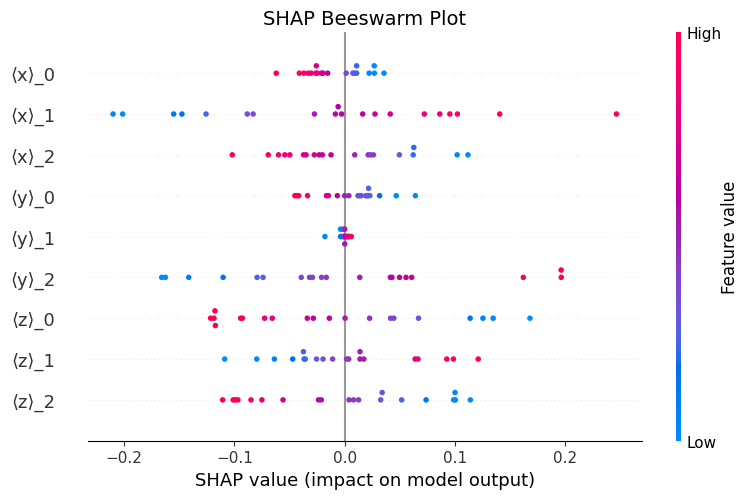

In [54]:
# Beeswarm plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
shap.plots.beeswarm(shap_values, order=range(len(input_labels)), show=False)
plt.title("SHAP Beeswarm Plot", fontsize=14)
plt.tight_layout()
if PLOT_SAVE:
    plt.savefig(save_dir_model + f"shap_beeswarm_plot.png", dpi=200)
plt.show()

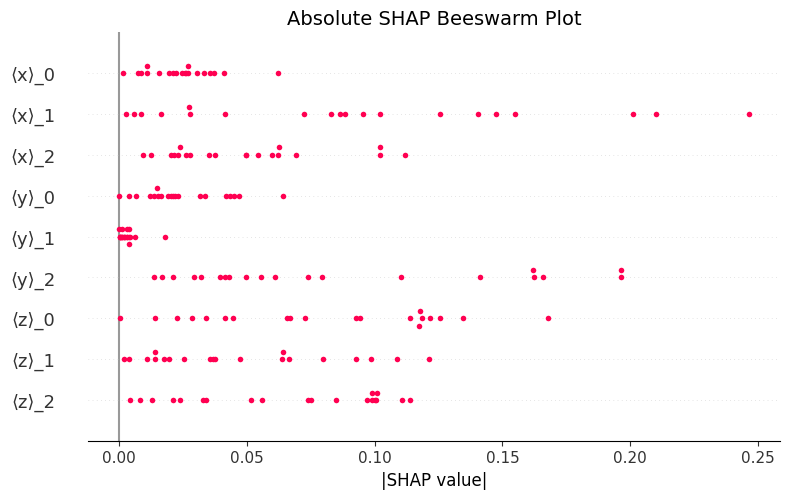

In [55]:
# Beeswarm plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
shap.plots.beeswarm(shap_values.abs, order=range(len(input_labels)), show=False,
                    color="shap_red")
plt.title("Absolute SHAP Beeswarm Plot", fontsize=14)
plt.xlabel("|SHAP value|", fontsize=12)
plt.tight_layout()
if PLOT_SAVE:
    plt.savefig(save_dir_model + f"shap_absolute_beeswarm_plot.png", dpi=200)
plt.show()

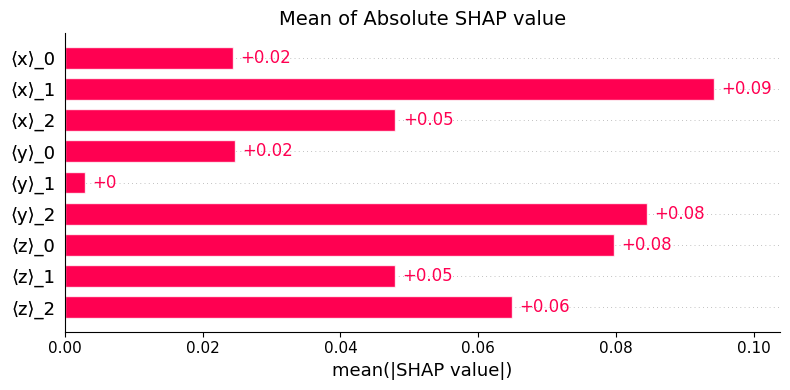

In [56]:
# Mean of Absolute SHAP value bar plot
import matplotlib.pyplot as plt

shap.plots.bar(shap_values.abs.mean(0), order=range(len(input_labels)), show=False)
fig = plt.gcf()
fig.set_size_inches(8, 4)
ax = plt.gca()
ax.set_title("Mean of Absolute SHAP value", fontsize=14)
plt.tight_layout()
# if PLOT_SAVE:
#     plt.savefig(save_dir_model + f"shap_absolute_mean_plot.png", dpi=200)
plt.show()

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

def mean_absolute_shap_barplot(
    shap_explanation, 
    axis=0,
    figsize=(6, 3),
    plot_save=False,
    save_dir='./'
):
    shap_vals = shap_explanation.values  # shape (n_samples, n_features)

    # Always take absolute value
    shap_vals = np.abs(shap_vals)

    # Step 2: take mean across specified axis
    shap_vals = shap_vals.mean(axis)

    feature_names = shap_explanation.feature_names
    n_features = len(feature_names)

    fig, ax = plt.subplots(figsize=figsize)

    # Step 3: horizontal bar plot
    gap_factor = 0.6
    y_pos = np.arange(n_features) * gap_factor

    red_color = "#ff0066"
    blue_color = "#0099ff"

    colors = [red_color if v >= 0 else blue_color for v in shap_vals]

    bars = ax.barh(
        y_pos, 
        shap_vals, 
        color=colors, 
        edgecolor='none',
        height=0.4
    )

    # Step 3.5: Expand xlim smartly
    x_min = shap_vals.min()
    x_max = shap_vals.max()

    buffer = 0.25 * x_max
    ax.set_xlim(0, x_max + buffer)

    # Step 4: y-axis feature labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=12)
    ax.invert_yaxis()

    # Step 5: Label and Title
    xlabel = "mean(|SHAP value|)"
    title = "Mean of Absolute SHAP value"

    ax.set_xlabel(xlabel, fontsize=14)
    # ax.set_ylabel("Feature", fontsize=14)
    ax.set_title(title, fontsize=16)

    # Step 6: Scientific notation for x-axis
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-5, 5))
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Step 7: Remove plot box (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    # Step 8: Grid
    ax.grid(axis='y', linestyle='--', alpha=0.2)

    # Step 9: Add value labels next to bars
    max_val = np.max(shap_vals)
    offset = 0.05 * max_val

    for bar, val in zip(bars, shap_vals):
        xpos = bar.get_width()
        ypos = bar.get_y() + bar.get_height() / 2

        label = f"{val:.2e}" if np.abs(val) >= 1e5 or np.abs(val) <= 1e-5 else f"{val:.4f}"
        ax.text(
            xpos + offset,
            ypos,
            label,
            va='center',
            ha='left',
            color=red_color,
            fontsize=12
        )

    plt.tight_layout()
    if plot_save:
        plt.savefig(save_dir_model + f"shap_absolute_mean_plot.png", dpi=200)
    plt.show()

In [58]:
shap_values.abs.mean(0)

.values =
array([0.02433543, 0.09415865, 0.0479383 , 0.02468246, 0.00290059,
       0.08449403, 0.07968505, 0.04791397, 0.06490924])

.base_values =
array([-0.1644794], dtype=float32)

.data =
array([0.32524413, 0.5211914 , 0.53583986, 0.5336914 , 0.50756836,
       0.45273438, 0.65786135, 0.44399413, 0.620166  ], dtype=float32)

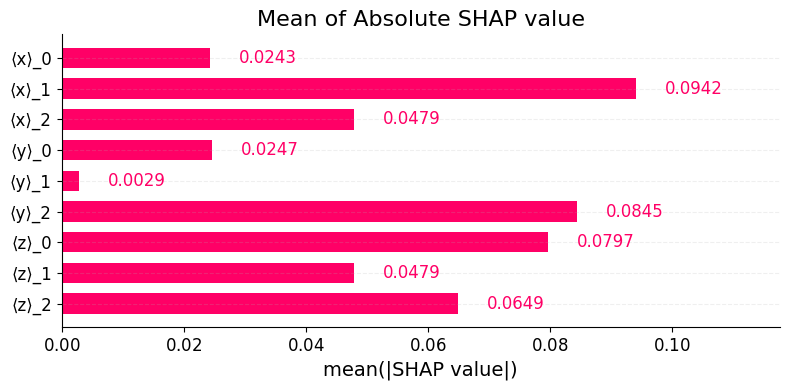

In [59]:
mean_absolute_shap_barplot(shap_values, figsize=(8, 4),
                           plot_save=PLOT_SAVE, save_dir=save_dir_model
                           )

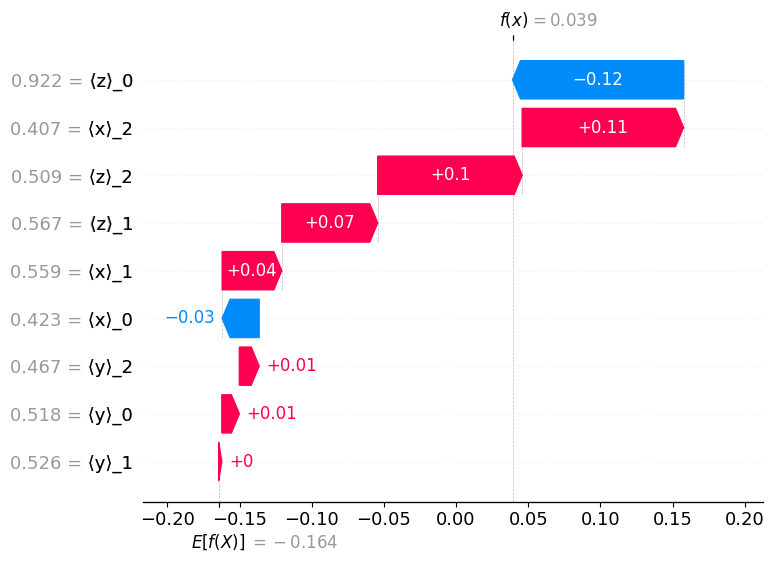

In [60]:
# Waterfall plot of a single data point
shap.plots.waterfall(shap_values[0])  # explain the 1st sample

# for j in range(len(test_dataset.data)):
#     shap.plots.waterfall(shap_values[j])

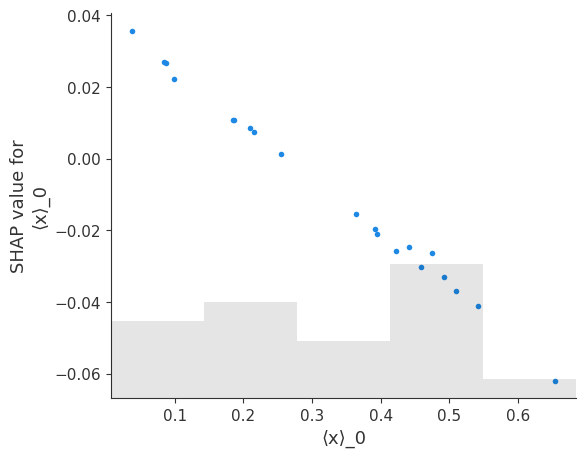

In [61]:
# Scatter plot of SHAP values between features
shap.plots.scatter(shap_values[:,0])

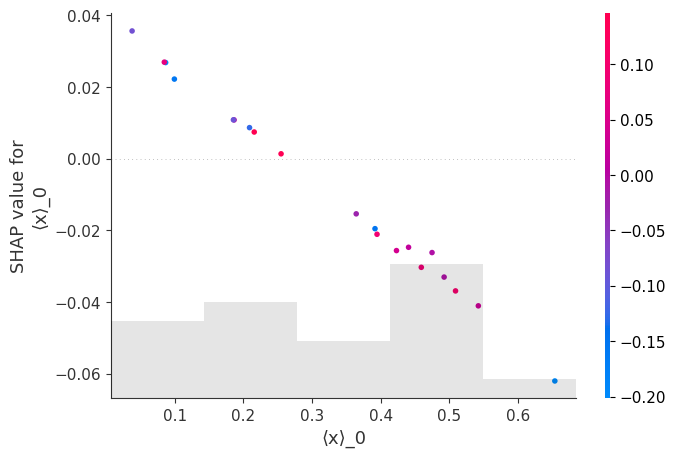

In [62]:
shap.plots.scatter(shap_values[:,input_labels[0]], color=shap_values.values[:,1])

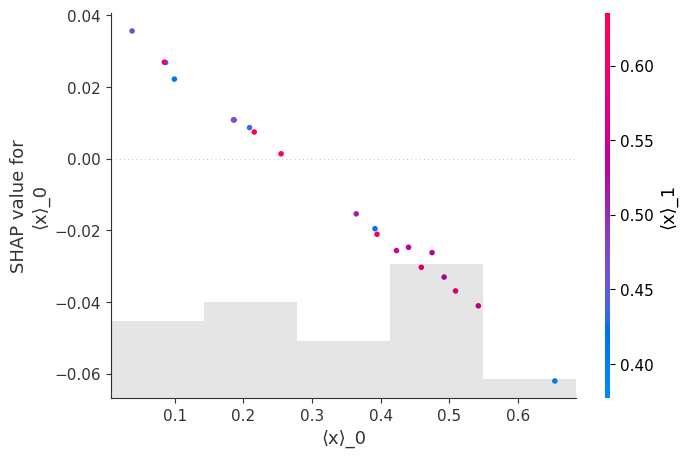

In [63]:
shap.plots.scatter(shap_values[:,0], color=shap_values)

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

def custom_shap_scatter_plot(
    feature_values,
    shap_values_feature,
    shap_values_color,
    feature_name="Feature",
    color_feature_name="Color Feature",
    figsize=(6, 4)
):
    fig, ax = plt.subplots(figsize=figsize)

    # SHAP-like colormap: magenta to blue
    shap_cmap = LinearSegmentedColormap.from_list("shap_cmap", ['#ff0066', '#0099ff'])

    # Scatter plot
    sc = ax.scatter(
        feature_values,
        shap_values_feature,
        c=shap_values_color,
        cmap=shap_cmap,
        s=35,
        edgecolors='none',
        zorder=3
    )

    # Overlay histogram (in same axis, background)
    hist_vals, bins = np.histogram(feature_values, bins='auto')
    hist_max_height = 0.3 * (shap_values_feature.max() - shap_values_feature.min())
    hist_vals = hist_vals / hist_vals.max() * hist_max_height

    bin_widths = np.diff(bins)
    bin_centers = bins[:-1]

    ax.bar(
        bin_centers,
        hist_vals,
        width=bin_widths,
        bottom=shap_values_feature.min() - hist_max_height * 1.2,  # nudge below the SHAP range
        color='gray',
        alpha=0.3,
        align='edge',
        zorder=1
    )

    # Axes labels
    title='SHAP dependence scatter plot'
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel(f"SHAP value for\n{feature_name}", fontsize=12)

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label(color_feature_name, fontsize=12)

    # Style
    ax.tick_params(axis='y', direction='out')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(False)

    plt.tight_layout()
    plt.show()


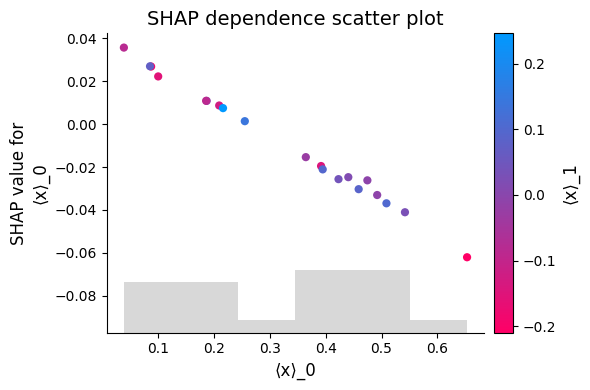

In [65]:
# SHAP dependence scatter plot

i, j = 0, 1
custom_shap_scatter_plot(
    feature_values=shap_values.data[:, i],
    shap_values_feature=shap_values.values[:, i],
    shap_values_color=shap_values.values[:, j],
    feature_name=input_labels[i],
    color_feature_name=input_labels[j]
)
